# Hyperparameter Optimization of MobileNetV3-Large and ResNet50

## Smart Waste Classification System Using Deep Learning

This notebook performs controlled hyperparameter optimization for the two
candidate architectures selected during the initial five-model comparison:

1. MobileNetV3-Large
2. ResNet50

MobileNetV3-Large was selected because it achieved the strongest predictive
performance and the most efficient CPU inference result.

ResNet50 was selected as the strongest alternative predictive architecture.

The tuning process uses only the training and validation splits for model
selection. The isolated test split remains untouched until the best
configuration for each candidate has been selected.

##  Optimization Objectives

The objectives of this notebook are to:

1. Reuse the same fixed train, validation, and test split manifest.
2. Preserve the same image preprocessing and augmentation policy.
3. Tune at least two candidate models as required by the project manual.
4. Investigate a limited and computationally defensible search space.
5. Tune the following parameters:

   - Backbone learning rate
   - Classifier learning rate
   - Weight decay
   - Dropout rate
   - Number or scope of fine-tuned feature blocks

6. Use validation loss as the primary checkpoint-selection metric.
7. Use validation accuracy and macro F1-score as supporting evidence.
8. Avoid using test performance for hyperparameter selection.
9. Save every trial result in a structured table.
10. Select one winning configuration per architecture.
11. Evaluate each winning tuned model once on the isolated test set.
12. Compare tuned results against the original model results.

The search is intentionally limited rather than exhaustive because the current
system uses CPU-based training.

##  Validation Strategy

Hyperparameters are model-development choices.

Using test accuracy to select learning rates, dropout, weight decay, or
fine-tuning depth would leak test-set information into the development process
and produce an optimistically biased final result.

Therefore:

- Training split: parameter optimization
- Validation split: trial comparison and checkpoint selection
- Test split: one final evaluation after configuration selection

The primary selection criterion is minimum validation loss.

When two configurations have similar validation loss, the following
tie-breakers are applied:

1. Higher validation macro F1-score
2. Higher validation accuracy
3. Lower model complexity
4. Lower training time

In [104]:
import gc
import json
import os
import platform
import random
import sys
import time

from copy import deepcopy
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    MobileNet_V3_Large_Weights,
    ResNet50_Weights,
    mobilenet_v3_large,
    resnet50,
)

In [105]:
print("=" * 76)
print("HYPERPARAMETER OPTIMIZATION ENVIRONMENT")
print("=" * 76)

print(f"Python executable : {sys.executable}")
print(f"Python version    : {platform.python_version()}")
print(f"PyTorch version   : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Operating system  : {platform.platform()}")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("-" * 76)
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"Selected device   : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("Hardware note     : CPU-only optimization environment")

print("=" * 76)

HYPERPARAMETER OPTIMIZATION ENVIRONMENT
Python executable : c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
Python version    : 3.12.10
PyTorch version   : 2.13.0+cpu
TorchVision       : 0.28.0+cpu
Operating system  : Windows-11-10.0.26200-SP0
----------------------------------------------------------------------------
CUDA available    : False
Selected device   : cpu
Hardware note     : CPU-only optimization environment


In [106]:
BASE_SEED = 42


def set_random_seed(seed: int) -> None:
    """
    Configure random generators used by Python, NumPy, and PyTorch.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_random_seed(BASE_SEED)

print(f"Base random seed configured: {BASE_SEED}")

Base random seed configured: 42


##  Shared Experiment Configuration

Both candidates use the same:

- Dataset manifest
- Image dimensions
- Batch size
- ImageNet normalization
- Augmentation policy
- Class-weighting method
- Training and validation functions
- Early-stopping rule
- Learning-rate scheduler

Only the declared tuning parameters are allowed to change between trials.

In [107]:
PROJECT_ROOT = Path("..")

DATA_DIRECTORY = PROJECT_ROOT / "data"
SPLITS_DIRECTORY = DATA_DIRECTORY / "splits"

MODEL_DIRECTORY = PROJECT_ROOT / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "results"
FIGURES_DIRECTORY = RESULTS_DIRECTORY / "figures"
LOGS_DIRECTORY = PROJECT_ROOT / "logs"

MODEL_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LOGS_DIRECTORY.mkdir(parents=True, exist_ok=True)

SPLIT_MANIFEST_PATH = (
    SPLITS_DIRECTORY
    / "split_manifest.csv"
)

MOBILENET_ORIGINAL_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_finetuned_best.pt"
)

RESNET50_ORIGINAL_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "resnet50_classifier_best.pt"
)

MOBILENET_TUNED_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_tuned_best.pt"
)

RESNET50_TUNED_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "resnet50_tuned_best.pt"
)

TRIAL_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "hyperparameter_tuning_trials.csv"
)

WINNING_CONFIGURATIONS_PATH = (
    RESULTS_DIRECTORY
    / "hyperparameter_tuning_winners.json"
)

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
)

BATCH_SIZE = 16
NUM_WORKERS = 0

TRIAL_EPOCHS = 3
FINAL_TUNING_EPOCHS = 6

EARLY_STOPPING_PATIENCE = 2
MINIMUM_IMPROVEMENT = 1e-4

print(f"Manifest path     : {SPLIT_MANIFEST_PATH.resolve()}")
print(f"Image size        : {IMAGE_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Trial epochs      : {TRIAL_EPOCHS}")
print(f"Final tune epochs : {FINAL_TUNING_EPOCHS}")
print(f"Device            : {DEVICE}")

Manifest path     : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\split_manifest.csv
Image size        : (224, 224)
Batch size        : 16
Trial epochs      : 3
Final tune epochs : 6
Device            : cpu


In [108]:
required_files = {
    "Split manifest": (
        SPLIT_MANIFEST_PATH
    ),
    "MobileNetV3 checkpoint": (
        MOBILENET_ORIGINAL_CHECKPOINT_PATH
    ),
    "ResNet50 checkpoint": (
        RESNET50_ORIGINAL_CHECKPOINT_PATH
    ),
}

required_file_status = pd.DataFrame(
    [
        {
            "required_file": file_name,
            "path": str(file_path),
            "exists": file_path.exists(),
        }
        for file_name, file_path
        in required_files.items()
    ]
)

display(required_file_status)

missing_required_files = (
    required_file_status[
        required_file_status["exists"] == False
    ]
)

if not missing_required_files.empty:
    display(missing_required_files)

    raise FileNotFoundError(
        "One or more required optimization inputs "
        "could not be found."
    )

print("All required optimization inputs were found.")

,required_file,path,exists
0,Split manifest,..\data\splits\split_manifest.csv,True
1,MobileNetV3 checkpoint,..\models\mobilenet_v3_large_finetuned_best.pt,True
2,ResNet50 checkpoint,..\models\resnet50_classifier_best.pt,True


All required optimization inputs were found.


##  Hyperparameter Search Strategy

A controlled manual grid is used instead of a large exhaustive search.

The search varies parameters that have a direct effect on transfer learning:

### MobileNetV3-Large

- Backbone learning rate
- Classifier learning rate
- Weight decay
- Dropout
- Number of final feature blocks unfrozen

### ResNet50

- Backbone learning rate
- Classifier learning rate
- Weight decay
- Dropout
- Fine-tuning scope

The search uses a small number of purposeful configurations rather than every
possible parameter combination.

This strategy is appropriate because:

- The dataset contains 2,521 images.
- Training is CPU-based.
- Large grid searches would be computationally excessive.
- The project requires justified optimization, not brute-force computation.

## MobileNetV3 trial configurations

In [109]:
MOBILENET_TRIAL_CONFIGURATIONS = [
    {
        "trial_name": "mobilenet_trial_1",
        "backbone_learning_rate": 1e-5,
        "classifier_learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout_rate": 0.30,
        "fine_tune_last_n_blocks": 3,
    },
    {
        "trial_name": "mobilenet_trial_2",
        "backbone_learning_rate": 3e-5,
        "classifier_learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout_rate": 0.30,
        "fine_tune_last_n_blocks": 3,
    },
    {
        "trial_name": "mobilenet_trial_3",
        "backbone_learning_rate": 1e-5,
        "classifier_learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "dropout_rate": 0.20,
        "fine_tune_last_n_blocks": 3,
    },
    {
        "trial_name": "mobilenet_trial_4",
        "backbone_learning_rate": 1e-5,
        "classifier_learning_rate": 1e-4,
        "weight_decay": 1e-5,
        "dropout_rate": 0.40,
        "fine_tune_last_n_blocks": 2,
    },
]

pd.DataFrame(
    MOBILENET_TRIAL_CONFIGURATIONS
)

,trial_name,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tune_last_n_blocks
0,mobilenet_trial_1,0.00001,0.0001,0.00010,0.3,3
1,mobilenet_trial_2,0.00003,0.0001,0.00010,0.3,3
2,mobilenet_trial_3,0.00001,0.0003,0.00010,0.2,3
3,mobilenet_trial_4,0.00001,0.0001,0.00001,0.4,2


## ResNet50 trial configurations

In [110]:
RESNET50_TRIAL_CONFIGURATIONS = [
    {
        "trial_name": "resnet50_trial_1",
        "backbone_learning_rate": 1e-5,
        "classifier_learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout_rate": 0.30,
        "unfreeze_layer4": True,
    },
    {
        "trial_name": "resnet50_trial_2",
        "backbone_learning_rate": 3e-5,
        "classifier_learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout_rate": 0.30,
        "unfreeze_layer4": True,
    },
    {
        "trial_name": "resnet50_trial_3",
        "backbone_learning_rate": 1e-5,
        "classifier_learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "dropout_rate": 0.20,
        "unfreeze_layer4": True,
    },
    {
        "trial_name": "resnet50_trial_4",
        "backbone_learning_rate": 1e-5,
        "classifier_learning_rate": 1e-4,
        "weight_decay": 1e-5,
        "dropout_rate": 0.40,
        "unfreeze_layer4": False,
    },
]

pd.DataFrame(
    RESNET50_TRIAL_CONFIGURATIONS
)

,trial_name,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,unfreeze_layer4
0,resnet50_trial_1,0.00001,0.0001,0.00010,0.3,True
1,resnet50_trial_2,0.00003,0.0001,0.00010,0.3,True
2,resnet50_trial_3,0.00001,0.0003,0.00010,0.2,True
3,resnet50_trial_4,0.00001,0.0001,0.00001,0.4,False


## Validate the search spaces

In [111]:
def validate_trial_configuration(
    configuration: dict,
    architecture: str,
) -> None:
    """
    Validate one hyperparameter configuration.
    """
    positive_parameters = [
        "backbone_learning_rate",
        "classifier_learning_rate",
        "weight_decay",
    ]

    for parameter_name in positive_parameters:
        if configuration[parameter_name] <= 0:
            raise ValueError(
                f"{architecture}: {parameter_name} "
                "must be greater than zero."
            )

    dropout_rate = configuration[
        "dropout_rate"
    ]

    if not 0.0 <= dropout_rate < 1.0:
        raise ValueError(
            f"{architecture}: dropout_rate must "
            "be between zero and one."
        )

    if architecture == "mobilenet_v3_large":
        if (
            configuration[
                "fine_tune_last_n_blocks"
            ]
            <= 0
        ):
            raise ValueError(
                "MobileNetV3 must fine-tune at "
                "least one feature block."
            )


for configuration in (
    MOBILENET_TRIAL_CONFIGURATIONS
):
    validate_trial_configuration(
        configuration,
        architecture=(
            "mobilenet_v3_large"
        ),
    )

for configuration in (
    RESNET50_TRIAL_CONFIGURATIONS
):
    validate_trial_configuration(
        configuration,
        architecture="resnet50",
    )

print(
    "All hyperparameter configurations "
    "were validated successfully."
)

All hyperparameter configurations were validated successfully.


##  Dataset Reuse and Leakage Prevention

The same split manifest used in all previous experiments is reused.

No new dataset split is created.

This ensures that tuning results remain directly comparable with the initial
model experiments and prevents accidental train-validation-test leakage.

In [112]:
if not SPLIT_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "Split manifest not found:\n"
        f"{SPLIT_MANIFEST_PATH.resolve()}"
    )

split_manifest = pd.read_csv(
    SPLIT_MANIFEST_PATH
)

required_manifest_columns = {
    "destination_path",
    "class_name",
    "split",
    "sha256",
}

missing_manifest_columns = (
    required_manifest_columns
    - set(split_manifest.columns)
)

if missing_manifest_columns:
    raise KeyError(
        "The split manifest is missing columns: "
        + ", ".join(
            sorted(
                missing_manifest_columns
            )
        )
    )

print(
    f"Split manifest loaded: "
    f"{len(split_manifest):,} records"
)

Split manifest loaded: 2,521 records


In [113]:
def resolve_image_path(
    stored_path: str,
    project_root: Path,
) -> Path:
    """
    Resolve a project-relative or absolute image path.
    """
    image_path = Path(stored_path)

    if image_path.is_absolute():
        return image_path

    return (
        project_root / image_path
    ).resolve()


split_manifest = split_manifest.copy()

split_manifest["resolved_path"] = (
    split_manifest[
        "destination_path"
    ]
    .apply(
        lambda stored_path: (
            resolve_image_path(
                stored_path=stored_path,
                project_root=PROJECT_ROOT,
            )
        )
    )
)

split_manifest["file_exists"] = (
    split_manifest["resolved_path"]
    .apply(Path.exists)
)

missing_images = split_manifest[
    split_manifest["file_exists"] == False
]

if not missing_images.empty:
    display(
        missing_images.head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_images)} images "
        "could not be found."
    )

print(
    f"All {len(split_manifest):,} image "
    "paths were verified."
)

All 2,521 image paths were verified.


In [114]:
hash_split_counts = (
    split_manifest
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_duplicates = (
    hash_split_counts[
        hash_split_counts > 1
    ]
)

if len(cross_split_duplicates) > 0:
    raise ValueError(
        "Cross-split duplicate image "
        "content was detected."
    )

print(
    "No duplicate image content was "
    "found across dataset splits."
)

No duplicate image content was found across dataset splits.


In [115]:
class_names = sorted(
    split_manifest[
        "class_name"
    ]
    .unique()
    .tolist()
)

class_to_index = {
    class_name: class_index
    for class_index, class_name
    in enumerate(class_names)
}

index_to_class = {
    class_index: class_name
    for class_name, class_index
    in class_to_index.items()
}

NUM_CLASSES = len(class_names)

split_manifest["class_index"] = (
    split_manifest[
        "class_name"
    ]
    .map(class_to_index)
    .astype(int)
)

train_manifest = (
    split_manifest[
        split_manifest["split"]
        == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_manifest = (
    split_manifest[
        split_manifest["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_manifest = (
    split_manifest[
        split_manifest["split"]
        == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Classes           : {NUM_CLASSES}")
print(f"Training images   : {len(train_manifest):,}")
print(f"Validation images : {len(validation_manifest):,}")
print(f"Test images       : {len(test_manifest):,}")

Classes           : 6
Training images   : 1,762
Validation images : 378
Test images       : 381


##  Shared Preprocessing and Augmentation

The tuning trials reuse the same preprocessing applied in the original transfer
learning experiments.

Changing augmentation during hyperparameter tuning would introduce an
additional experimental variable and weaken the fairness of the comparison.

Training images receive moderate augmentation. Validation and test images use
deterministic preprocessing.

In [116]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STANDARD_DEVIATION = [
    0.229,
    0.224,
    0.225,
]

training_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            size=IMAGE_SIZE,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.RandomHorizontalFlip(
            p=0.50,
        ),
        transforms.RandomRotation(
            degrees=10,
        ),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=(
                IMAGENET_STANDARD_DEVIATION
            ),
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=(
                IMAGENET_STANDARD_DEVIATION
            ),
        ),
    ]
)

print(
    "Shared tuning transforms configured."
)

Shared tuning transforms configured.


In [117]:
class WasteClassificationDataset(
    Dataset
):
    """
    Manifest-based TrashNet dataset.
    """

    def __init__(
        self,
        manifest: pd.DataFrame,
        transform=None,
    ) -> None:
        self.manifest = (
            manifest.copy()
            .reset_index(drop=True)
        )

        self.transform = transform

    def __len__(self) -> int:
        return len(
            self.manifest
        )

    def __getitem__(
        self,
        index: int,
    ) -> dict:
        record = self.manifest.iloc[
            index
        ]

        image_path = Path(
            record["resolved_path"]
        )

        class_index = int(
            record["class_index"]
        )

        try:
            with Image.open(
                image_path
            ) as image:
                image = image.convert(
                    "RGB"
                )

        except (
            FileNotFoundError,
            UnidentifiedImageError,
            OSError,
        ) as error:
            raise RuntimeError(
                f"Unable to load image: "
                f"{image_path}"
            ) from error

        if self.transform is not None:
            image = self.transform(
                image
            )

        return {
            "image": image,
            "label": class_index,
            "path": str(image_path),
        }

In [118]:
train_dataset = (
    WasteClassificationDataset(
        manifest=train_manifest,
        transform=training_transform,
    )
)

validation_dataset = (
    WasteClassificationDataset(
        manifest=validation_manifest,
        transform=evaluation_transform,
    )
)

test_dataset = (
    WasteClassificationDataset(
        manifest=test_manifest,
        transform=evaluation_transform,
    )
)


def create_data_loaders(
    seed: int,
) -> tuple:
    """
    Create reproducible data loaders for one trial.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
        generator=generator,
    )

    validation_loader = DataLoader(
        dataset=validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    return (
        train_loader,
        validation_loader,
        test_loader,
    )


(
    train_loader,
    validation_loader,
    test_loader,
) = create_data_loaders(
    BASE_SEED
)

print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(validation_loader)}")
print(f"Test batches       : {len(test_loader)}")

Training batches   : 111
Validation batches : 24
Test batches       : 24


In [119]:
training_class_counts = (
    train_manifest[
        "class_name"
    ]
    .value_counts()
    .reindex(class_names)
)

class_weights_array = (
    len(train_manifest)
    / (
        NUM_CLASSES
        * training_class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE,
)

class_weight_table = pd.DataFrame(
    {
        "class_name": class_names,
        "training_samples": (
            training_class_counts.values
        ),
        "class_weight": (
            class_weights_array
        ),
    }
)

class_weight_table

,class_name,training_samples,class_weight
0,cardboard,282,1.041371
1,glass,348,0.843870
2,metal,286,1.026807
3,paper,415,0.707631
4,plastic,336,0.874008
5,trash,95,3.091228


##  Candidate Model Construction

Each tuning trial begins from the same original pretrained architecture.

The trial does not continue from weights produced by another tuning
configuration. This prevents one trial from receiving an unfair advantage from
previous optimization.

For each architecture:

- ImageNet-pretrained weights initialize the feature extractor.
- The original classifier is replaced for six TrashNet classes.
- The requested upper layers are unfrozen.
- Batch Normalization parameters remain frozen.
- Separate learning rates are applied to the backbone and classifier.

In [120]:
def freeze_batch_normalization(
    model: nn.Module,
) -> int:
    """
    Freeze Batch Normalization parameters.

    Returns
    -------
    int
        Number of Batch Normalization modules found.
    """
    batch_norm_count = 0

    for module in model.modules():
        if isinstance(
            module,
            (
                nn.BatchNorm1d,
                nn.BatchNorm2d,
                nn.BatchNorm3d,
            ),
        ):
            batch_norm_count += 1
            module.eval()

            for parameter in module.parameters():
                parameter.requires_grad = False

    return batch_norm_count

## Build MobileNetV3-Large for one trial

In [121]:
def build_mobilenet_trial_model(
    configuration: dict,
    device: torch.device,
) -> tuple[nn.Module, dict]:
    """
    Build MobileNetV3-Large for one tuning trial.
    """
    model = mobilenet_v3_large(
        weights=MobileNet_V3_Large_Weights.DEFAULT
    )

    classifier_input_features = (
        model.classifier[3].in_features
    )

    model.classifier[2] = nn.Dropout(
        p=configuration["dropout_rate"],
        inplace=True,
    )

    model.classifier[3] = nn.Linear(
        in_features=classifier_input_features,
        out_features=NUM_CLASSES,
    )

    # Freeze the complete model first.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Keep the complete classification head trainable.
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True

    number_of_feature_blocks = len(
        model.features
    )

    fine_tune_last_n_blocks = int(
        configuration[
            "fine_tune_last_n_blocks"
        ]
    )

    if not (
        1
        <= fine_tune_last_n_blocks
        <= number_of_feature_blocks
    ):
        raise ValueError(
            "Invalid MobileNetV3 fine-tuning depth."
        )

    first_trainable_block_index = (
        number_of_feature_blocks
        - fine_tune_last_n_blocks
    )

    for block in model.features[
        first_trainable_block_index:
    ]:
        for parameter in block.parameters():
            parameter.requires_grad = True

    batch_norm_count = (
        freeze_batch_normalization(
            model
        )
    )

    model = model.to(device)

    trainability_metadata = {
        "number_of_feature_blocks": (
            number_of_feature_blocks
        ),
        "fine_tune_last_n_blocks": (
            fine_tune_last_n_blocks
        ),
        "first_trainable_block_index": (
            first_trainable_block_index
        ),
        "frozen_batch_norm_modules": (
            batch_norm_count
        ),
    }

    return model, trainability_metadata

## Build ResNet50 for one trial

In [122]:
def build_resnet50_trial_model(
    configuration: dict,
    device: torch.device,
) -> tuple[nn.Module, dict]:
    """
    Build ResNet50 for one tuning trial.
    """
    model = resnet50(
        weights=ResNet50_Weights.DEFAULT
    )

    classifier_input_features = (
        model.fc.in_features
    )

    model.fc = nn.Sequential(
        nn.Dropout(
            p=configuration["dropout_rate"],
        ),
        nn.Linear(
            in_features=classifier_input_features,
            out_features=NUM_CLASSES,
        ),
    )

    # Freeze the complete network first.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Keep the classification head trainable.
    for parameter in model.fc.parameters():
        parameter.requires_grad = True

    if configuration["unfreeze_layer4"]:
        for parameter in (
            model.layer4.parameters()
        ):
            parameter.requires_grad = True

        fine_tuning_scope = (
            "layer4_and_classifier"
        )

    else:
        fine_tuning_scope = (
            "classifier_only"
        )

    batch_norm_count = (
        freeze_batch_normalization(
            model
        )
    )

    model = model.to(device)

    trainability_metadata = {
        "unfreeze_layer4": bool(
            configuration[
                "unfreeze_layer4"
            ]
        ),
        "fine_tuning_scope": (
            fine_tuning_scope
        ),
        "frozen_batch_norm_modules": (
            batch_norm_count
        ),
    }

    return model, trainability_metadata

In [123]:
def count_parameters(
    model: nn.Module,
) -> dict:
    """
    Count total, trainable, and frozen parameters.
    """
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return {
        "total_parameters": int(
            total_parameters
        ),
        "trainable_parameters": int(
            trainable_parameters
        ),
        "frozen_parameters": int(
            total_parameters
            - trainable_parameters
        ),
    }

In [124]:
mobilenet_smoke_model, mobilenet_smoke_metadata = (
    build_mobilenet_trial_model(
        configuration=(
            MOBILENET_TRIAL_CONFIGURATIONS[0]
        ),
        device=DEVICE,
    )
)

resnet50_smoke_model, resnet50_smoke_metadata = (
    build_resnet50_trial_model(
        configuration=(
            RESNET50_TRIAL_CONFIGURATIONS[0]
        ),
        device=DEVICE,
    )
)

sample_batch = next(
    iter(train_loader)
)

sample_images = sample_batch[
    "image"
].to(DEVICE)

with torch.inference_mode():
    mobilenet_smoke_logits = (
        mobilenet_smoke_model(
            sample_images
        )
    )

    resnet50_smoke_logits = (
        resnet50_smoke_model(
            sample_images
        )
    )

print(
    "MobileNet output shape:",
    mobilenet_smoke_logits.shape,
)

print(
    "ResNet50 output shape:",
    resnet50_smoke_logits.shape,
)

print("\nMobileNet tuning metadata:")
print(mobilenet_smoke_metadata)

print("\nResNet50 tuning metadata:")
print(resnet50_smoke_metadata)

MobileNet output shape: torch.Size([16, 6])
ResNet50 output shape: torch.Size([16, 6])

MobileNet tuning metadata:
{'number_of_feature_blocks': 17, 'fine_tune_last_n_blocks': 3, 'first_trainable_block_index': 14, 'frozen_batch_norm_modules': 46}

ResNet50 tuning metadata:
{'unfreeze_layer4': True, 'fine_tuning_scope': 'layer4_and_classifier', 'frozen_batch_norm_modules': 53}


In [125]:
expected_shape = (
    sample_images.shape[0],
    NUM_CLASSES,
)

if tuple(
    mobilenet_smoke_logits.shape
) != expected_shape:
    raise ValueError(
        "MobileNetV3 trial model output "
        "shape is incorrect."
    )

if tuple(
    resnet50_smoke_logits.shape
) != expected_shape:
    raise ValueError(
        "ResNet50 trial model output "
        "shape is incorrect."
    )

print(
    "Both candidate model builders "
    "passed the forward-pass test."
)

del mobilenet_smoke_model
del resnet50_smoke_model
del mobilenet_smoke_logits
del resnet50_smoke_logits

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Both candidate model builders passed the forward-pass test.


##  Trial Training and Validation Utilities

Each tuning trial records:

- Training loss
- Training accuracy
- Validation loss
- Validation accuracy
- Validation macro F1-score
- Epoch duration
- Learning rates

Validation loss is the primary configuration-selection metric.

Macro F1-score is also recorded because it treats all six waste classes equally
and provides evidence about minority-class performance.

In [126]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> dict:
    """
    Train one complete epoch.
    """
    model.train()

    # Preserve pretrained BatchNorm behavior.
    for module in model.modules():
        if isinstance(
            module,
            (
                nn.BatchNorm1d,
                nn.BatchNorm2d,
                nn.BatchNorm3d,
            ),
        ):
            module.eval()

    running_loss = 0.0
    correct_predictions = 0
    processed_samples = 0

    for batch in data_loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = batch["label"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = loss_function(
            logits,
            labels,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite training loss detected."
            )

        loss.backward()
        optimizer.step()

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        correct_predictions += int(
            (
                predictions == labels
            )
            .sum()
            .item()
        )

        processed_samples += batch_size

    if processed_samples == 0:
        raise RuntimeError(
            "Training loader returned no samples."
        )

    return {
        "loss": float(
            running_loss
            / processed_samples
        ),
        "accuracy": float(
            correct_predictions
            / processed_samples
        ),
        "sample_count": int(
            processed_samples
        ),
    }

In [127]:
def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate one complete validation epoch.
    """
    model.eval()

    running_loss = 0.0
    processed_samples = 0

    true_labels = []
    predicted_labels = []

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Non-finite validation "
                    "loss detected."
                )

            predictions = torch.argmax(
                logits,
                dim=1,
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            processed_samples += (
                batch_size
            )

            true_labels.extend(
                labels.cpu().tolist()
            )

            predicted_labels.extend(
                predictions.cpu().tolist()
            )

    if processed_samples == 0:
        raise RuntimeError(
            "Validation loader returned no samples."
        )

    validation_accuracy = (
        accuracy_score(
            true_labels,
            predicted_labels,
        )
    )

    (
        _,
        _,
        validation_macro_f1,
        _,
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        average="macro",
        zero_division=0,
    )

    return {
        "loss": float(
            running_loss
            / processed_samples
        ),
        "accuracy": float(
            validation_accuracy
        ),
        "macro_f1": float(
            validation_macro_f1
        ),
        "sample_count": int(
            processed_samples
        ),
    }

In [128]:
def create_trial_optimizer(
    model: nn.Module,
    architecture: str,
    configuration: dict,
) -> torch.optim.Optimizer:
    """
    Create an Adam optimizer with differential learning rates.
    """
    if architecture == "mobilenet_v3_large":
        backbone_parameters = [
            parameter
            for parameter
            in model.features.parameters()
            if parameter.requires_grad
        ]

        classifier_parameters = [
            parameter
            for parameter
            in model.classifier.parameters()
            if parameter.requires_grad
        ]

    elif architecture == "resnet50":
        backbone_parameters = [
            parameter
            for parameter
            in model.layer4.parameters()
            if parameter.requires_grad
        ]

        classifier_parameters = [
            parameter
            for parameter
            in model.fc.parameters()
            if parameter.requires_grad
        ]

    else:
        raise ValueError(
            f"Unsupported architecture: "
            f"{architecture}"
        )

    parameter_groups = []

    if backbone_parameters:
        parameter_groups.append(
            {
                "params": (
                    backbone_parameters
                ),
                "lr": configuration[
                    "backbone_learning_rate"
                ],
                "group_name": "backbone",
            }
        )

    if not classifier_parameters:
        raise RuntimeError(
            "No trainable classifier "
            "parameters were found."
        )

    parameter_groups.append(
        {
            "params": (
                classifier_parameters
            ),
            "lr": configuration[
                "classifier_learning_rate"
            ],
            "group_name": "classifier",
        }
    )

    return Adam(
        parameter_groups,
        weight_decay=configuration[
            "weight_decay"
        ],
    )

In [129]:
def save_trial_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    architecture: str,
    configuration: dict,
    metadata: dict,
    epoch: int,
    validation_metrics: dict,
) -> None:
    """
    Save the best checkpoint for one tuning trial.
    """
    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint = {
        "architecture": architecture,
        "configuration": deepcopy(
            configuration
        ),
        "trainability_metadata": deepcopy(
            metadata
        ),
        "epoch": int(epoch),
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_loss": float(
            validation_metrics["loss"]
        ),
        "validation_accuracy": float(
            validation_metrics[
                "accuracy"
            ]
        ),
        "validation_macro_f1": float(
            validation_metrics[
                "macro_f1"
            ]
        ),
        "class_names": list(
            class_names
        ),
        "class_to_index": dict(
            class_to_index
        ),
        "image_size": list(
            IMAGE_SIZE
        ),
        "saved_at": (
            datetime.now().isoformat()
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

In [130]:
def run_tuning_trial(
    architecture: str,
    configuration: dict,
    trial_index: int,
) -> tuple[dict, pd.DataFrame]:
    """
    Run one complete validation-based tuning trial.
    """
    trial_seed = (
        BASE_SEED + trial_index
    )

    set_random_seed(
        trial_seed
    )

    (
        trial_train_loader,
        trial_validation_loader,
        _,
    ) = create_data_loaders(
        trial_seed
    )

    if architecture == "mobilenet_v3_large":
        model, trainability_metadata = (
            build_mobilenet_trial_model(
                configuration=configuration,
                device=DEVICE,
            )
        )

    elif architecture == "resnet50":
        model, trainability_metadata = (
            build_resnet50_trial_model(
                configuration=configuration,
                device=DEVICE,
            )
        )

    else:
        raise ValueError(
            f"Unsupported architecture: "
            f"{architecture}"
        )

    parameter_summary = count_parameters(
        model
    )

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )

    optimizer = create_trial_optimizer(
        model=model,
        architecture=architecture,
        configuration=configuration,
    )

    scheduler = ReduceLROnPlateau(
        optimizer=optimizer,
        mode="min",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
    )

    trial_name = configuration[
        "trial_name"
    ]

    trial_checkpoint_path = (
        MODEL_DIRECTORY
        / f"{trial_name}_best.pt"
    )

    best_validation_loss = float(
        "inf"
    )

    best_validation_accuracy = None
    best_validation_macro_f1 = None
    best_epoch = None

    non_improving_epochs = 0
    history_records = []

    trial_start_time = (
        time.perf_counter()
    )

    print("=" * 80)
    print(
        f"Starting {trial_name}"
    )
    print(
        f"Architecture: {architecture}"
    )
    print(
        f"Seed: {trial_seed}"
    )
    print(
        f"Configuration: {configuration}"
    )
    print("=" * 80)

    for epoch_index in range(
        TRIAL_EPOCHS
    ):
        epoch_number = (
            epoch_index + 1
        )

        epoch_start_time = (
            time.perf_counter()
        )

        learning_rates = [
            parameter_group["lr"]
            for parameter_group
            in optimizer.param_groups
        ]

        training_metrics = (
            train_one_epoch(
                model=model,
                data_loader=(
                    trial_train_loader
                ),
                loss_function=(
                    loss_function
                ),
                optimizer=optimizer,
                device=DEVICE,
            )
        )

        validation_metrics = (
            validate_one_epoch(
                model=model,
                data_loader=(
                    trial_validation_loader
                ),
                loss_function=(
                    loss_function
                ),
                device=DEVICE,
            )
        )

        scheduler.step(
            validation_metrics["loss"]
        )

        improved = (
            validation_metrics["loss"]
            < (
                best_validation_loss
                - MINIMUM_IMPROVEMENT
            )
        )

        if improved:
            best_validation_loss = (
                validation_metrics[
                    "loss"
                ]
            )

            best_validation_accuracy = (
                validation_metrics[
                    "accuracy"
                ]
            )

            best_validation_macro_f1 = (
                validation_metrics[
                    "macro_f1"
                ]
            )

            best_epoch = epoch_number
            non_improving_epochs = 0

            save_trial_checkpoint(
                checkpoint_path=(
                    trial_checkpoint_path
                ),
                model=model,
                optimizer=optimizer,
                architecture=architecture,
                configuration=(
                    configuration
                ),
                metadata=(
                    trainability_metadata
                ),
                epoch=epoch_number,
                validation_metrics=(
                    validation_metrics
                ),
            )

        else:
            non_improving_epochs += 1

        epoch_duration_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        history_records.append(
            {
                "architecture": (
                    architecture
                ),
                "trial_name": (
                    trial_name
                ),
                "epoch": (
                    epoch_number
                ),
                "train_loss": (
                    training_metrics[
                        "loss"
                    ]
                ),
                "train_accuracy": (
                    training_metrics[
                        "accuracy"
                    ]
                ),
                "validation_loss": (
                    validation_metrics[
                        "loss"
                    ]
                ),
                "validation_accuracy": (
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                "validation_macro_f1": (
                    validation_metrics[
                        "macro_f1"
                    ]
                ),
                "learning_rates": (
                    ",".join(
                        f"{rate:.10f}"
                        for rate
                        in learning_rates
                    )
                ),
                "checkpoint_saved": (
                    improved
                ),
                "epoch_duration_seconds": (
                    epoch_duration_seconds
                ),
            }
        )

        print(
            f"Epoch {epoch_number}/{TRIAL_EPOCHS}"
        )

        print(
            f"  Train loss: "
            f"{training_metrics['loss']:.4f}"
        )

        print(
            f"  Train accuracy: "
            f"{training_metrics['accuracy']:.4f}"
        )

        print(
            f"  Validation loss: "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"  Validation accuracy: "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"  Validation macro F1: "
            f"{validation_metrics['macro_f1']:.4f}"
        )

        print(
            f"  Best checkpoint saved: "
            f"{improved}"
        )

        if (
            non_improving_epochs
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "  Early stopping activated."
            )
            break

    total_trial_duration_seconds = (
        time.perf_counter()
        - trial_start_time
    )

    trial_result = {
        "architecture": architecture,
        "trial_name": trial_name,
        "trial_seed": trial_seed,
        "backbone_learning_rate": (
            configuration[
                "backbone_learning_rate"
            ]
        ),
        "classifier_learning_rate": (
            configuration[
                "classifier_learning_rate"
            ]
        ),
        "weight_decay": (
            configuration[
                "weight_decay"
            ]
        ),
        "dropout_rate": (
            configuration[
                "dropout_rate"
            ]
        ),
        "fine_tuning_scope": str(
            trainability_metadata
        ),
        "best_epoch": (
            best_epoch
        ),
        "best_validation_loss": float(
            best_validation_loss
        ),
        "best_validation_accuracy": float(
            best_validation_accuracy
        ),
        "best_validation_macro_f1": float(
            best_validation_macro_f1
        ),
        "total_parameters": (
            parameter_summary[
                "total_parameters"
            ]
        ),
        "trainable_parameters": (
            parameter_summary[
                "trainable_parameters"
            ]
        ),
        "trial_duration_seconds": float(
            total_trial_duration_seconds
        ),
        "checkpoint_path": str(
            trial_checkpoint_path
        ),
    }

    history_dataframe = pd.DataFrame(
        history_records
    )

    del model
    del optimizer
    del scheduler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        trial_result,
        history_dataframe,
    )

In [131]:
ORIGINAL_TRIAL_EPOCHS = TRIAL_EPOCHS
TRIAL_EPOCHS = 1

smoke_trial_result, smoke_trial_history = (
    run_tuning_trial(
        architecture="mobilenet_v3_large",
        configuration=(
            MOBILENET_TRIAL_CONFIGURATIONS[0]
        ),
        trial_index=100,
    )
)

display(
    pd.DataFrame(
        [smoke_trial_result]
    )
)

display(
    smoke_trial_history
)

TRIAL_EPOCHS = ORIGINAL_TRIAL_EPOCHS

Starting mobilenet_trial_1
Architecture: mobilenet_v3_large
Seed: 142
Configuration: {'trial_name': 'mobilenet_trial_1', 'backbone_learning_rate': 1e-05, 'classifier_learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropout_rate': 0.3, 'fine_tune_last_n_blocks': 3}
Epoch 1/1
  Train loss: 1.0791
  Train accuracy: 0.6635
  Validation loss: 0.6261
  Validation accuracy: 0.7937
  Validation macro F1: 0.7675
  Best checkpoint saved: True


,architecture,trial_name,trial_seed,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tuning_scope,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,total_parameters,trainable_parameters,trial_duration_seconds,checkpoint_path
0,mobilenet_v3_large,mobilenet_trial_1,142,0.00001,0.0001,0.0001,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",1,0.626054,0.793651,0.767487,4209718,2977766,98.097872,..\models\mobilenet_trial_1_best.pt


,architecture,trial_name,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,validation_macro_f1,learning_rates,checkpoint_saved,epoch_duration_seconds
0,mobilenet_v3_large,mobilenet_trial_1,1,1.079073,0.663451,0.626054,0.793651,0.767487,"0.0000100000,0.0001000000",True,98.096782


In [132]:
smoke_checkpoint_path = Path(
    smoke_trial_result[
        "checkpoint_path"
    ]
)

if not smoke_checkpoint_path.exists():
    raise FileNotFoundError(
        "The tuning smoke-test checkpoint "
        "was not created."
    )

print(
    "Tuning pipeline smoke test passed."
)

Tuning pipeline smoke test passed.


##  MobileNetV3-Large Tuning Trials

Four controlled MobileNetV3-Large trials are performed.

The isolated test split is not used during these trials. Configuration ranking
is based entirely on validation results.

In [133]:
all_trial_results = []
all_trial_histories = []

for trial_index, configuration in enumerate(
    MOBILENET_TRIAL_CONFIGURATIONS,
    start=1,
):
    trial_result, trial_history = (
        run_tuning_trial(
            architecture=(
                "mobilenet_v3_large"
            ),
            configuration=(
                configuration
            ),
            trial_index=(
                trial_index
            ),
        )
    )

    all_trial_results.append(
        trial_result
    )

    all_trial_histories.append(
        trial_history
    )

mobilenet_trial_results = pd.DataFrame(
    all_trial_results
)

mobilenet_trial_results

Starting mobilenet_trial_1
Architecture: mobilenet_v3_large
Seed: 43
Configuration: {'trial_name': 'mobilenet_trial_1', 'backbone_learning_rate': 1e-05, 'classifier_learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropout_rate': 0.3, 'fine_tune_last_n_blocks': 3}
Epoch 1/3
  Train loss: 1.0797
  Train accuracy: 0.6589
  Validation loss: 0.6474
  Validation accuracy: 0.7619
  Validation macro F1: 0.7398
  Best checkpoint saved: True
Epoch 2/3
  Train loss: 0.4909
  Train accuracy: 0.8371
  Validation loss: 0.5176
  Validation accuracy: 0.8307
  Validation macro F1: 0.8109
  Best checkpoint saved: True
Epoch 3/3
  Train loss: 0.3515
  Train accuracy: 0.8740
  Validation loss: 0.4593
  Validation accuracy: 0.8439
  Validation macro F1: 0.8250
  Best checkpoint saved: True
Starting mobilenet_trial_2
Architecture: mobilenet_v3_large
Seed: 44
Configuration: {'trial_name': 'mobilenet_trial_2', 'backbone_learning_rate': 3e-05, 'classifier_learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropou

,architecture,trial_name,trial_seed,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tuning_scope,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,total_parameters,trainable_parameters,trial_duration_seconds,checkpoint_path
0,mobilenet_v3_large,mobilenet_trial_1,43,0.00001,0.0001,0.00010,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.459280,0.843915,0.825030,4209718,2977766,270.709832,..\models\mobilenet_trial_1_best.pt
1,mobilenet_v3_large,mobilenet_trial_2,44,0.00003,0.0001,0.00010,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.396164,0.867725,0.847907,4209718,2977766,267.822278,..\models\mobilenet_trial_2_best.pt
2,mobilenet_v3_large,mobilenet_trial_3,45,0.00001,0.0003,0.00010,0.2,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.392689,0.867725,0.853999,4209718,2977766,264.219638,..\models\mobilenet_trial_3_best.pt
3,mobilenet_v3_large,mobilenet_trial_4,46,0.00001,0.0001,0.00001,0.4,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.459768,0.846561,0.830002,4209718,2184566,256.598582,..\models\mobilenet_trial_4_best.pt


##  ResNet50 Tuning Trials

Four controlled ResNet50 trials are performed using the same training and
validation partitions.

The search compares classifier-only adaptation against controlled fine-tuning
of the final residual stage.

In [134]:
resnet_trial_offset = len(
    MOBILENET_TRIAL_CONFIGURATIONS
)

for trial_index, configuration in enumerate(
    RESNET50_TRIAL_CONFIGURATIONS,
    start=1,
):
    trial_result, trial_history = (
        run_tuning_trial(
            architecture="resnet50",
            configuration=configuration,
            trial_index=(
                resnet_trial_offset
                + trial_index
            ),
        )
    )

    all_trial_results.append(
        trial_result
    )

    all_trial_histories.append(
        trial_history
    )

resnet50_trial_results = pd.DataFrame(
    [
        result
        for result in all_trial_results
        if result["architecture"]
        == "resnet50"
    ]
)

resnet50_trial_results

Starting resnet50_trial_1
Architecture: resnet50
Seed: 47
Configuration: {'trial_name': 'resnet50_trial_1', 'backbone_learning_rate': 1e-05, 'classifier_learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropout_rate': 0.3, 'unfreeze_layer4': True}
Epoch 1/3
  Train loss: 1.3669
  Train accuracy: 0.5375
  Validation loss: 0.8168
  Validation accuracy: 0.7593
  Validation macro F1: 0.7334
  Best checkpoint saved: True
Epoch 2/3
  Train loss: 0.5954
  Train accuracy: 0.8053
  Validation loss: 0.5389
  Validation accuracy: 0.8386
  Validation macro F1: 0.8136
  Best checkpoint saved: True
Epoch 3/3
  Train loss: 0.3883
  Train accuracy: 0.8632
  Validation loss: 0.4723
  Validation accuracy: 0.8519
  Validation macro F1: 0.8298
  Best checkpoint saved: True
Starting resnet50_trial_2
Architecture: resnet50
Seed: 48
Configuration: {'trial_name': 'resnet50_trial_2', 'backbone_learning_rate': 3e-05, 'classifier_learning_rate': 0.0001, 'weight_decay': 0.0001, 'dropout_rate': 0.3, 'unfreeze_layer

,architecture,trial_name,trial_seed,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tuning_scope,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,total_parameters,trainable_parameters,trial_duration_seconds,checkpoint_path
0,resnet50,resnet50_trial_1,47,0.00001,0.0001,0.00010,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.472302,0.851852,0.829818,23520326,14954502,1065.344947,..\models\resnet50_trial_1_best.pt
1,resnet50,resnet50_trial_2,48,0.00003,0.0001,0.00010,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.365053,0.896825,0.880083,23520326,14954502,1075.041231,..\models\resnet50_trial_2_best.pt
2,resnet50,resnet50_trial_3,49,0.00001,0.0003,0.00010,0.2,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.440809,0.859788,0.833459,23520326,14954502,1042.359015,..\models\resnet50_trial_3_best.pt
3,resnet50,resnet50_trial_4,50,0.00001,0.0001,0.00001,0.4,"{'unfreeze_layer4': False, 'fine_tuning_scope'...",3,1.174170,0.791005,0.762389,23520326,12294,843.510665,..\models\resnet50_trial_4_best.pt


In [135]:
trial_results = pd.DataFrame(
    all_trial_results
)

trial_history = pd.concat(
    all_trial_histories,
    ignore_index=True,
)

trial_results.to_csv(
    TRIAL_RESULTS_PATH,
    index=False,
)

TRIAL_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "hyperparameter_tuning_history.csv"
)

trial_history.to_csv(
    TRIAL_HISTORY_PATH,
    index=False,
)

print(
    "Trial results saved to:"
)

print(
    TRIAL_RESULTS_PATH.resolve()
)

print(
    "\nTrial history saved to:"
)

print(
    TRIAL_HISTORY_PATH.resolve()
)

trial_results

Trial results saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\hyperparameter_tuning_trials.csv

Trial history saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\logs\hyperparameter_tuning_history.csv


,architecture,trial_name,trial_seed,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tuning_scope,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,total_parameters,trainable_parameters,trial_duration_seconds,checkpoint_path
0,mobilenet_v3_large,mobilenet_trial_1,43,0.00001,0.0001,0.00010,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.459280,0.843915,0.825030,4209718,2977766,270.709832,..\models\mobilenet_trial_1_best.pt
1,mobilenet_v3_large,mobilenet_trial_2,44,0.00003,0.0001,0.00010,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.396164,0.867725,0.847907,4209718,2977766,267.822278,..\models\mobilenet_trial_2_best.pt
2,mobilenet_v3_large,mobilenet_trial_3,45,0.00001,0.0003,0.00010,0.2,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.392689,0.867725,0.853999,4209718,2977766,264.219638,..\models\mobilenet_trial_3_best.pt
3,mobilenet_v3_large,mobilenet_trial_4,46,0.00001,0.0001,0.00001,0.4,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.459768,0.846561,0.830002,4209718,2184566,256.598582,..\models\mobilenet_trial_4_best.pt
4,resnet50,resnet50_trial_1,47,0.00001,0.0001,0.00010,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.472302,0.851852,0.829818,23520326,14954502,1065.344947,..\models\resnet50_trial_1_best.pt
5,resnet50,resnet50_trial_2,48,0.00003,0.0001,0.00010,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.365053,0.896825,0.880083,23520326,14954502,1075.041231,..\models\resnet50_trial_2_best.pt
6,resnet50,resnet50_trial_3,49,0.00001,0.0003,0.00010,0.2,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.440809,0.859788,0.833459,23520326,14954502,1042.359015,..\models\resnet50_trial_3_best.pt
7,resnet50,resnet50_trial_4,50,0.00001,0.0001,0.00001,0.4,"{'unfreeze_layer4': False, 'fine_tuning_scope'...",3,1.174170,0.791005,0.762389,23520326,12294,843.510665,..\models\resnet50_trial_4_best.pt


##  Validation-Based Trial Ranking

Configurations are ranked independently within each architecture.

The ranking order is:

1. Lowest validation loss
2. Highest validation macro F1-score
3. Highest validation accuracy
4. Fewer trainable parameters
5. Shorter trial duration

The test set does not influence this ranking.

In [136]:
trial_ranking = (
    trial_results
    .sort_values(
        by=[
            "architecture",
            "best_validation_loss",
            "best_validation_macro_f1",
            "best_validation_accuracy",
            "trainable_parameters",
            "trial_duration_seconds",
        ],
        ascending=[
            True,
            True,
            False,
            False,
            True,
            True,
        ],
    )
    .copy()
)

trial_ranking[
    "architecture_rank"
] = (
    trial_ranking
    .groupby("architecture")
    .cumcount()
    + 1
)

trial_ranking

,architecture,trial_name,trial_seed,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tuning_scope,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,total_parameters,trainable_parameters,trial_duration_seconds,checkpoint_path,architecture_rank
2,mobilenet_v3_large,mobilenet_trial_3,45,0.00001,0.0003,0.00010,0.2,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.392689,0.867725,0.853999,4209718,2977766,264.219638,..\models\mobilenet_trial_3_best.pt,1
1,mobilenet_v3_large,mobilenet_trial_2,44,0.00003,0.0001,0.00010,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.396164,0.867725,0.847907,4209718,2977766,267.822278,..\models\mobilenet_trial_2_best.pt,2
0,mobilenet_v3_large,mobilenet_trial_1,43,0.00001,0.0001,0.00010,0.3,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.459280,0.843915,0.825030,4209718,2977766,270.709832,..\models\mobilenet_trial_1_best.pt,3
3,mobilenet_v3_large,mobilenet_trial_4,46,0.00001,0.0001,0.00001,0.4,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.459768,0.846561,0.830002,4209718,2184566,256.598582,..\models\mobilenet_trial_4_best.pt,4
5,resnet50,resnet50_trial_2,48,0.00003,0.0001,0.00010,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.365053,0.896825,0.880083,23520326,14954502,1075.041231,..\models\resnet50_trial_2_best.pt,1
6,resnet50,resnet50_trial_3,49,0.00001,0.0003,0.00010,0.2,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.440809,0.859788,0.833459,23520326,14954502,1042.359015,..\models\resnet50_trial_3_best.pt,2
4,resnet50,resnet50_trial_1,47,0.00001,0.0001,0.00010,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.472302,0.851852,0.829818,23520326,14954502,1065.344947,..\models\resnet50_trial_1_best.pt,3
7,resnet50,resnet50_trial_4,50,0.00001,0.0001,0.00001,0.4,"{'unfreeze_layer4': False, 'fine_tuning_scope'...",3,1.174170,0.791005,0.762389,23520326,12294,843.510665,..\models\resnet50_trial_4_best.pt,4


In [137]:
winning_trials = (
    trial_ranking[
        trial_ranking[
            "architecture_rank"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

if len(winning_trials) != 2:
    raise ValueError(
        "Exactly one winning trial per "
        "architecture was expected."
    )

winning_trials

,architecture,trial_name,trial_seed,backbone_learning_rate,classifier_learning_rate,weight_decay,dropout_rate,fine_tuning_scope,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,total_parameters,trainable_parameters,trial_duration_seconds,checkpoint_path,architecture_rank
0,mobilenet_v3_large,mobilenet_trial_3,45,0.00001,0.0003,0.0001,0.2,"{'number_of_feature_blocks': 17, 'fine_tune_la...",3,0.392689,0.867725,0.853999,4209718,2977766,264.219638,..\models\mobilenet_trial_3_best.pt,1
1,resnet50,resnet50_trial_2,48,0.00003,0.0001,0.0001,0.3,"{'unfreeze_layer4': True, 'fine_tuning_scope':...",3,0.365053,0.896825,0.880083,23520326,14954502,1075.041231,..\models\resnet50_trial_2_best.pt,1


In [138]:
winning_configuration_records = {}

for _, winning_row in winning_trials.iterrows():

    architecture = winning_row["architecture"]

    if architecture == "mobilenet_v3_large":
        configuration_list = MOBILENET_TRIAL_CONFIGURATIONS
    else:
        configuration_list = RESNET50_TRIAL_CONFIGURATIONS

    configuration = next(
        cfg
        for cfg in configuration_list
        if cfg["trial_name"] == winning_row["trial_name"]
    )

    checkpoint_path = (
        MODEL_DIRECTORY
        / f"{configuration['trial_name']}_best.pt"
    ).resolve()

    winning_configuration_records[architecture] = {

        "configuration": configuration,

        "best_epoch": int(
            winning_row["best_epoch"]
        ),

        "validation_loss": float(
            winning_row["best_validation_loss"]
        ),

        "validation_accuracy": float(
            winning_row["best_validation_accuracy"]
        ),

        "validation_macro_f1": float(
            winning_row["best_validation_macro_f1"]
        ),

        "trial_checkpoint_path": str(
            checkpoint_path
        ),
    }

with open(
    WINNING_CONFIGURATIONS_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        winning_configuration_records,
        file,
        indent=4,
    )

print(json.dumps(
    winning_configuration_records,
    indent=2,
))


{
  "mobilenet_v3_large": {
    "configuration": {
      "trial_name": "mobilenet_trial_3",
      "backbone_learning_rate": 1e-05,
      "classifier_learning_rate": 0.0003,
      "weight_decay": 0.0001,
      "dropout_rate": 0.2,
      "fine_tune_last_n_blocks": 3
    },
    "best_epoch": 3,
    "validation_loss": 0.3926890938685685,
    "validation_accuracy": 0.8677248677248677,
    "validation_macro_f1": 0.8539987079695637,
    "trial_checkpoint_path": "C:\\Users\\Mudassar Iqbal Shah\\Documents\\Internship\\smart-waste-classification\\models\\mobilenet_trial_3_best.pt"
  },
  "resnet50": {
    "configuration": {
      "trial_name": "resnet50_trial_2",
      "backbone_learning_rate": 3e-05,
      "classifier_learning_rate": 0.0001,
      "weight_decay": 0.0001,
      "dropout_rate": 0.3,
      "unfreeze_layer4": true
    },
    "best_epoch": 3,
    "validation_loss": 0.3650533377178132,
    "validation_accuracy": 0.8968253968253969,
    "validation_macro_f1": 0.8800833126540911,
    "

##  Extended Training of the Winning Configurations

The short tuning trials were designed to compare hyperparameter configurations,
not to produce the final optimized models.

The winning checkpoint from each architecture is now used as the starting point
for a longer final optimization stage.

For each architecture:

1. Reconstruct the model using the winning configuration.
2. Load the best checkpoint produced during the trial search.
3. Recreate the optimizer using the winning learning rates and weight decay.
4. Continue training using only the training split.
5. Monitor performance using only the validation split.
6. Save the checkpoint with the lowest validation loss.
7. Apply early stopping if validation performance stops improving.

The isolated test split remains unused until both final tuned checkpoints have
been selected.

In [139]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)


In [140]:
FINAL_TUNING_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "final_tuned_training_history.csv"
)

FINAL_TUNED_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "final_tuned_candidate_results.csv"
)

FINAL_TUNED_RESULTS_JSON_PATH = (
    RESULTS_DIRECTORY
    / "final_tuned_candidate_results.json"
)

MOBILENET_TUNED_DEPLOYMENT_PATH = (
    MODEL_DIRECTORY
    / "mobilenet_v3_large_tuned_deployment.pt"
)

RESNET50_TUNED_DEPLOYMENT_PATH = (
    MODEL_DIRECTORY
    / "resnet50_tuned_deployment.pt"
)

print("Final-tuning output paths configured.")

Final-tuning output paths configured.


In [141]:
def build_winning_model(
    architecture: str,
    configuration: dict,
    device: torch.device,
) -> tuple[nn.Module, dict]:
    """
    Reconstruct one candidate using its winning configuration.
    """
    if architecture == "mobilenet_v3_large":
        return build_mobilenet_trial_model(
            configuration=configuration,
            device=device,
        )

    if architecture == "resnet50":
        return build_resnet50_trial_model(
            configuration=configuration,
            device=device,
        )

    raise ValueError(
        f"Unsupported architecture: {architecture}"
    )

In [142]:
def load_winning_trial_checkpoint(
    architecture: str,
    winning_record: dict,
    device: torch.device,
) -> tuple[nn.Module, dict, dict]:
    """
    Reconstruct a winning model and load its trial checkpoint.
    """
    configuration = winning_record[
        "configuration"
    ]

    checkpoint_path = Path(
        winning_record[
            "trial_checkpoint_path"
        ]
    )

    if not checkpoint_path.is_absolute():
        checkpoint_path = (
            PROJECT_ROOT
            / checkpoint_path
        ).resolve()

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            "Winning trial checkpoint was not found:\n"
            f"{checkpoint_path}"
        )

    model, trainability_metadata = (
        build_winning_model(
            architecture=architecture,
            configuration=configuration,
            device=device,
        )
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    if (
        checkpoint.get("architecture")
        != architecture
    ):
        raise ValueError(
            "Checkpoint architecture mismatch. "
            f"Expected {architecture}, received "
            f"{checkpoint.get('architecture')}."
        )

    if (
        checkpoint.get("class_names")
        != class_names
    ):
        raise ValueError(
            "Checkpoint class names do not match "
            "the current project mapping."
        )

    if (
        checkpoint.get("class_to_index")
        != class_to_index
    ):
        raise ValueError(
            "Checkpoint class-to-index mapping "
            "does not match."
        )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model = model.to(device)

    return (
        model,
        trainability_metadata,
        checkpoint,
    )

In [143]:
mobilenet_winning_record = (
    winning_configuration_records[
        "mobilenet_v3_large"
    ]
)

resnet50_winning_record = (
    winning_configuration_records[
        "resnet50"
    ]
)

(
    mobilenet_winning_model,
    mobilenet_winning_metadata,
    mobilenet_winning_checkpoint,
) = load_winning_trial_checkpoint(
    architecture="mobilenet_v3_large",
    winning_record=(
        mobilenet_winning_record
    ),
    device=DEVICE,
)

(
    resnet50_winning_model,
    resnet50_winning_metadata,
    resnet50_winning_checkpoint,
) = load_winning_trial_checkpoint(
    architecture="resnet50",
    winning_record=(
        resnet50_winning_record
    ),
    device=DEVICE,
)

verification_batch = next(
    iter(validation_loader)
)

verification_images = (
    verification_batch["image"]
    .to(DEVICE)
)

with torch.inference_mode():
    mobilenet_verification_logits = (
        mobilenet_winning_model(
            verification_images
        )
    )

    resnet50_verification_logits = (
        resnet50_winning_model(
            verification_images
        )
    )

expected_shape = (
    verification_images.shape[0],
    NUM_CLASSES,
)

print(
    "MobileNetV3 output:",
    mobilenet_verification_logits.shape,
)

print(
    "ResNet50 output:",
    resnet50_verification_logits.shape,
)

if tuple(
    mobilenet_verification_logits.shape
) != expected_shape:
    raise ValueError(
        "The winning MobileNetV3 checkpoint "
        "produced an invalid output shape."
    )

if tuple(
    resnet50_verification_logits.shape
) != expected_shape:
    raise ValueError(
        "The winning ResNet50 checkpoint "
        "produced an invalid output shape."
    )

print(
    "Both winning trial checkpoints "
    "were reconstructed successfully."
)

MobileNetV3 output: torch.Size([16, 6])
ResNet50 output: torch.Size([16, 6])
Both winning trial checkpoints were reconstructed successfully.


In [144]:
del mobilenet_winning_model
del mobilenet_verification_logits
del resnet50_verification_logits

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [145]:
def save_final_tuned_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    architecture: str,
    configuration: dict,
    trainability_metadata: dict,
    epoch: int,
    validation_metrics: dict,
) -> None:
    """
    Save the best checkpoint from extended final tuning.
    """
    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint = {
        "architecture": architecture,
        "model_version": "tuned-1.0.0",
        "training_stage": (
            "extended_final_tuning"
        ),
        "configuration": deepcopy(
            configuration
        ),
        "trainability_metadata": deepcopy(
            trainability_metadata
        ),
        "epoch": int(epoch),
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_loss": float(
            validation_metrics["loss"]
        ),
        "validation_accuracy": float(
            validation_metrics[
                "accuracy"
            ]
        ),
        "validation_macro_f1": float(
            validation_metrics[
                "macro_f1"
            ]
        ),
        "number_of_classes": (
            NUM_CLASSES
        ),
        "class_names": list(
            class_names
        ),
        "class_to_index": dict(
            class_to_index
        ),
        "image_size": list(
            IMAGE_SIZE
        ),
        "normalization_mean": list(
            IMAGENET_MEAN
        ),
        "normalization_std": list(
            IMAGENET_STANDARD_DEVIATION
        ),
        "saved_at": (
            datetime.now().isoformat()
        ),
        "pytorch_version": (
            torch.__version__
        ),
        "torchvision_version": (
            torchvision.__version__
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

In [146]:
def run_extended_final_tuning(
    architecture: str,
    winning_record: dict,
    final_checkpoint_path: Path,
    seed: int,
) -> tuple[dict, pd.DataFrame]:
    """
    Continue training one winning trial configuration.

    Selection remains based entirely on validation loss.
    """
    set_random_seed(seed)

    (
        final_train_loader,
        final_validation_loader,
        _,
    ) = create_data_loaders(
        seed
    )

    model, trainability_metadata, trial_checkpoint = (
        load_winning_trial_checkpoint(
            architecture=architecture,
            winning_record=winning_record,
            device=DEVICE,
        )
    )

    configuration = winning_record[
        "configuration"
    ]

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )

    optimizer = create_trial_optimizer(
        model=model,
        architecture=architecture,
        configuration=configuration,
    )

    # Load the optimizer state from the winning trial
    # when its parameter-group structure matches.
    try:
        optimizer.load_state_dict(
            trial_checkpoint[
                "optimizer_state_dict"
            ]
        )

        optimizer_state_restored = True

    except (
        ValueError,
        KeyError,
    ):
        optimizer_state_restored = False

    scheduler = ReduceLROnPlateau(
        optimizer=optimizer,
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
    )

    initial_validation_loss = float(
        winning_record[
            "validation_loss"
        ]
    )

    best_validation_loss = (
        initial_validation_loss
    )

    best_validation_accuracy = float(
        winning_record[
            "validation_accuracy"
        ]
    )

    best_validation_macro_f1 = float(
        winning_record[
            "validation_macro_f1"
        ]
    )

    best_epoch = int(
        winning_record[
            "best_epoch"
        ]
    )

    non_improving_epochs = 0
    history_records = []

    stage_start_time = (
        time.perf_counter()
    )

    print("=" * 80)
    print(
        f"EXTENDED FINAL TUNING: "
        f"{architecture}"
    )
    print("=" * 80)

    print(
        "Winning trial:",
        configuration[
            "trial_name"
        ],
    )

    print(
        "Optimizer state restored:",
        optimizer_state_restored,
    )

    print(
        "Starting validation loss:",
        f"{best_validation_loss:.4f}",
    )

    for epoch_index in range(
        FINAL_TUNING_EPOCHS
    ):
        continuation_epoch = (
            epoch_index + 1
        )

        epoch_start_time = (
            time.perf_counter()
        )

        learning_rates = [
            group["lr"]
            for group
            in optimizer.param_groups
        ]

        training_metrics = train_one_epoch(
            model=model,
            data_loader=final_train_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            device=DEVICE,
        )

        validation_metrics = (
            validate_one_epoch(
                model=model,
                data_loader=(
                    final_validation_loader
                ),
                loss_function=loss_function,
                device=DEVICE,
            )
        )

        scheduler.step(
            validation_metrics[
                "loss"
            ]
        )

        validation_improved = (
            validation_metrics["loss"]
            < (
                best_validation_loss
                - MINIMUM_IMPROVEMENT
            )
        )

        if validation_improved:
            best_validation_loss = (
                validation_metrics[
                    "loss"
                ]
            )

            best_validation_accuracy = (
                validation_metrics[
                    "accuracy"
                ]
            )

            best_validation_macro_f1 = (
                validation_metrics[
                    "macro_f1"
                ]
            )

            best_epoch = (
                continuation_epoch
            )

            non_improving_epochs = 0

            save_final_tuned_checkpoint(
                checkpoint_path=(
                    final_checkpoint_path
                ),
                model=model,
                optimizer=optimizer,
                architecture=architecture,
                configuration=configuration,
                trainability_metadata=(
                    trainability_metadata
                ),
                epoch=continuation_epoch,
                validation_metrics=(
                    validation_metrics
                ),
            )

        else:
            non_improving_epochs += 1

        epoch_duration_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        history_records.append(
            {
                "architecture": (
                    architecture
                ),
                "winning_trial": (
                    configuration[
                        "trial_name"
                    ]
                ),
                "continuation_epoch": (
                    continuation_epoch
                ),
                "train_loss": (
                    training_metrics[
                        "loss"
                    ]
                ),
                "train_accuracy": (
                    training_metrics[
                        "accuracy"
                    ]
                ),
                "validation_loss": (
                    validation_metrics[
                        "loss"
                    ]
                ),
                "validation_accuracy": (
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                "validation_macro_f1": (
                    validation_metrics[
                        "macro_f1"
                    ]
                ),
                "learning_rates": ",".join(
                    f"{rate:.10f}"
                    for rate
                    in learning_rates
                ),
                "checkpoint_saved": (
                    validation_improved
                ),
                "epoch_duration_seconds": (
                    epoch_duration_seconds
                ),
            }
        )

        print("-" * 80)

        print(
            f"Continuation epoch "
            f"{continuation_epoch}/"
            f"{FINAL_TUNING_EPOCHS}"
        )

        print(
            f"Training loss       : "
            f"{training_metrics['loss']:.4f}"
        )

        print(
            f"Training accuracy   : "
            f"{training_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation loss     : "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"Validation accuracy : "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation macro F1 : "
            f"{validation_metrics['macro_f1']:.4f}"
        )

        print(
            "Checkpoint saved    :",
            validation_improved,
        )

        print(
            f"Early-stop counter  : "
            f"{non_improving_epochs}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

        if (
            non_improving_epochs
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping activated."
            )
            break

    total_duration_seconds = (
        time.perf_counter()
        - stage_start_time
    )

    # It is possible that no continuation epoch beats
    # the original short-trial checkpoint.
    if not final_checkpoint_path.exists():
        source_checkpoint_path = Path(
            winning_record[
                "trial_checkpoint_path"
            ]
        )

        if not source_checkpoint_path.is_absolute():
            source_checkpoint_path = (
                PROJECT_ROOT
                / source_checkpoint_path
            ).resolve()

        original_checkpoint = torch.load(
            source_checkpoint_path,
            map_location=DEVICE,
            weights_only=False,
        )

        fallback_checkpoint = deepcopy(
            original_checkpoint
        )

        fallback_checkpoint[
            "training_stage"
        ] = (
            "winning_trial_retained_after_"
            "extended_tuning"
        )

        fallback_checkpoint[
            "model_version"
        ] = "tuned-1.0.0"

        torch.save(
            fallback_checkpoint,
            final_checkpoint_path,
        )

        final_source = (
            "original winning trial checkpoint"
        )

    else:
        final_source = (
            "extended final-tuning checkpoint"
        )

    result = {
        "architecture": architecture,
        "winning_trial": (
            configuration[
                "trial_name"
            ]
        ),
        "best_epoch": int(
            best_epoch
        ),
        "best_validation_loss": float(
            best_validation_loss
        ),
        "best_validation_accuracy": float(
            best_validation_accuracy
        ),
        "best_validation_macro_f1": float(
            best_validation_macro_f1
        ),
        "training_duration_seconds": float(
            total_duration_seconds
        ),
        "optimizer_state_restored": bool(
            optimizer_state_restored
        ),
        "final_checkpoint_path": str(
            final_checkpoint_path
        ),
        "final_checkpoint_source": (
            final_source
        ),
    }

    history = pd.DataFrame(
        history_records
    )

    del model
    del optimizer
    del scheduler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, history

In [147]:
for stale_checkpoint_path in [
    MOBILENET_TUNED_CHECKPOINT_PATH,
    RESNET50_TUNED_CHECKPOINT_PATH,
]:
    if stale_checkpoint_path.exists():
        stale_checkpoint_path.unlink()

        print(
            "Removed stale checkpoint:",
            stale_checkpoint_path.name,
        )

In [148]:
(
    mobilenet_final_tuning_result,
    mobilenet_final_tuning_history,
) = run_extended_final_tuning(
    architecture="mobilenet_v3_large",
    winning_record=(
        mobilenet_winning_record
    ),
    final_checkpoint_path=(
        MOBILENET_TUNED_CHECKPOINT_PATH
    ),
    seed=BASE_SEED + 200,
)

display(
    pd.DataFrame(
        [
            mobilenet_final_tuning_result
        ]
    )
)

display(
    mobilenet_final_tuning_history
)

EXTENDED FINAL TUNING: mobilenet_v3_large
Winning trial: mobilenet_trial_3
Optimizer state restored: True
Starting validation loss: 0.3927
--------------------------------------------------------------------------------
Continuation epoch 1/6
Training loss       : 0.1790
Training accuracy   : 0.9353
Validation loss     : 0.3865
Validation accuracy : 0.8783
Validation macro F1 : 0.8593
Checkpoint saved    : True
Early-stop counter  : 0/2
--------------------------------------------------------------------------------
Continuation epoch 2/6
Training loss       : 0.1231
Training accuracy   : 0.9597
Validation loss     : 0.3661
Validation accuracy : 0.8915
Validation macro F1 : 0.8741
Checkpoint saved    : True
Early-stop counter  : 0/2
--------------------------------------------------------------------------------
Continuation epoch 3/6
Training loss       : 0.0888
Training accuracy   : 0.9711
Validation loss     : 0.3911
Validation accuracy : 0.8889
Validation macro F1 : 0.8692
Checkpoi

,architecture,winning_trial,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,training_duration_seconds,optimizer_state_restored,final_checkpoint_path,final_checkpoint_source
0,mobilenet_v3_large,mobilenet_trial_3,4,0.283189,0.888889,0.877591,562.782852,True,..\models\mobilenet_v3_large_tuned_best.pt,extended final-tuning checkpoint


,architecture,winning_trial,continuation_epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,validation_macro_f1,learning_rates,checkpoint_saved,epoch_duration_seconds
0,mobilenet_v3_large,mobilenet_trial_3,1,0.178973,0.935301,0.386532,0.878307,0.859255,"0.0000100000,0.0003000000",True,93.906981
1,mobilenet_v3_large,mobilenet_trial_3,2,0.123118,0.959705,0.366068,0.891534,0.874098,"0.0000100000,0.0003000000",True,96.574667
2,mobilenet_v3_large,mobilenet_trial_3,3,0.088838,0.971056,0.391134,0.888889,0.869193,"0.0000100000,0.0003000000",False,90.740439
3,mobilenet_v3_large,mobilenet_trial_3,4,0.077345,0.974461,0.283189,0.888889,0.877591,"0.0000100000,0.0003000000",True,93.033206
4,mobilenet_v3_large,mobilenet_trial_3,5,0.051022,0.983541,0.359312,0.883598,0.857964,"0.0000100000,0.0003000000",False,92.949272
5,mobilenet_v3_large,mobilenet_trial_3,6,0.067089,0.976731,0.317781,0.902116,0.894152,"0.0000100000,0.0003000000",False,95.573543


In [149]:
(
    resnet50_final_tuning_result,
    resnet50_final_tuning_history,
) = run_extended_final_tuning(
    architecture="resnet50",
    winning_record=(
        resnet50_winning_record
    ),
    final_checkpoint_path=(
        RESNET50_TUNED_CHECKPOINT_PATH
    ),
    seed=BASE_SEED + 300,
)

display(
    pd.DataFrame(
        [
            resnet50_final_tuning_result
        ]
    )
)

display(
    resnet50_final_tuning_history
)

EXTENDED FINAL TUNING: resnet50
Winning trial: resnet50_trial_2
Optimizer state restored: True
Starting validation loss: 0.3651
--------------------------------------------------------------------------------
Continuation epoch 1/6
Training loss       : 0.1623
Training accuracy   : 0.9421
Validation loss     : 0.4055
Validation accuracy : 0.8942
Validation macro F1 : 0.8735
Checkpoint saved    : False
Early-stop counter  : 1/2
--------------------------------------------------------------------------------
Continuation epoch 2/6
Training loss       : 0.0928
Training accuracy   : 0.9699
Validation loss     : 0.5657
Validation accuracy : 0.8598
Validation macro F1 : 0.8471
Checkpoint saved    : False
Early-stop counter  : 2/2
Early stopping activated.


,architecture,winning_trial,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,training_duration_seconds,optimizer_state_restored,final_checkpoint_path,final_checkpoint_source
0,resnet50,resnet50_trial_2,3,0.365053,0.896825,0.880083,719.985847,True,..\models\resnet50_tuned_best.pt,original winning trial checkpoint


,architecture,winning_trial,continuation_epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,validation_macro_f1,learning_rates,checkpoint_saved,epoch_duration_seconds
0,resnet50,resnet50_trial_2,1,0.162282,0.942111,0.405479,0.894180,0.873467,"0.0000300000,0.0001000000",False,359.344723
1,resnet50,resnet50_trial_2,2,0.092803,0.969921,0.565738,0.859788,0.847078,"0.0000300000,0.0001000000",False,360.639371


In [150]:
final_tuning_results = pd.DataFrame(
    [
        mobilenet_final_tuning_result,
        resnet50_final_tuning_result,
    ]
)

final_tuning_history = pd.concat(
    [
        mobilenet_final_tuning_history,
        resnet50_final_tuning_history,
    ],
    ignore_index=True,
)

final_tuning_history.to_csv(
    FINAL_TUNING_HISTORY_PATH,
    index=False,
)

print(
    "Final-tuning history saved to:"
)

print(
    FINAL_TUNING_HISTORY_PATH.resolve()
)

display(
    final_tuning_results
)

Final-tuning history saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\logs\final_tuned_training_history.csv


,architecture,winning_trial,best_epoch,best_validation_loss,best_validation_accuracy,best_validation_macro_f1,training_duration_seconds,optimizer_state_restored,final_checkpoint_path,final_checkpoint_source
0,mobilenet_v3_large,mobilenet_trial_3,4,0.283189,0.888889,0.877591,562.782852,True,..\models\mobilenet_v3_large_tuned_best.pt,extended final-tuning checkpoint
1,resnet50,resnet50_trial_2,3,0.365053,0.896825,0.880083,719.985847,True,..\models\resnet50_tuned_best.pt,original winning trial checkpoint


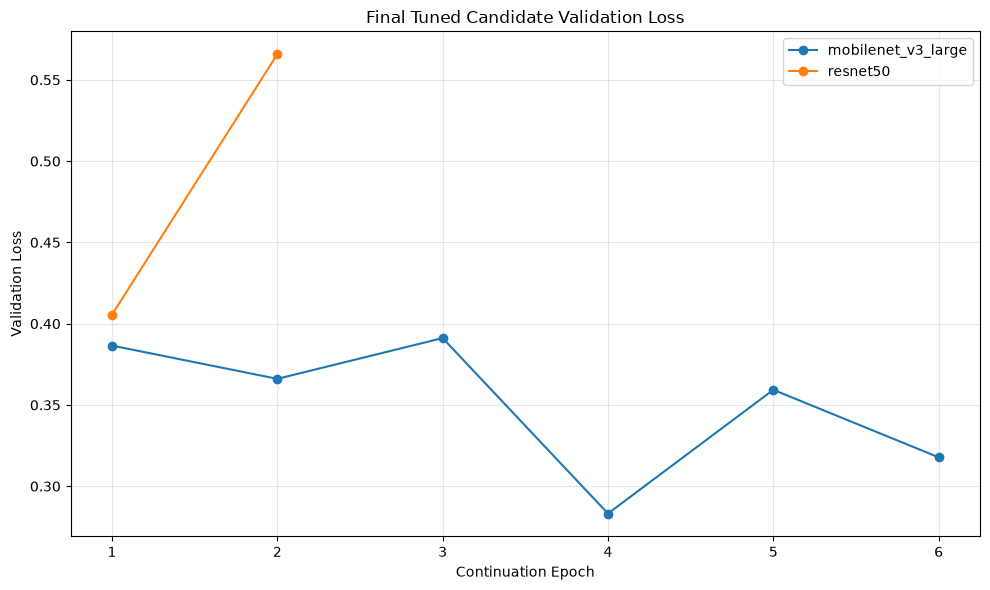

In [151]:
plt.figure(
    figsize=(10, 6)
)

for architecture, architecture_history in (
    final_tuning_history.groupby(
        "architecture"
    )
):
    plt.plot(
        architecture_history[
            "continuation_epoch"
        ],
        architecture_history[
            "validation_loss"
        ],
        marker="o",
        label=architecture,
    )

plt.xlabel(
    "Continuation Epoch"
)

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Final Tuned Candidate Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

FINAL_TUNING_LOSS_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "final_tuned_validation_loss.png"
)

plt.savefig(
    FINAL_TUNING_LOSS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

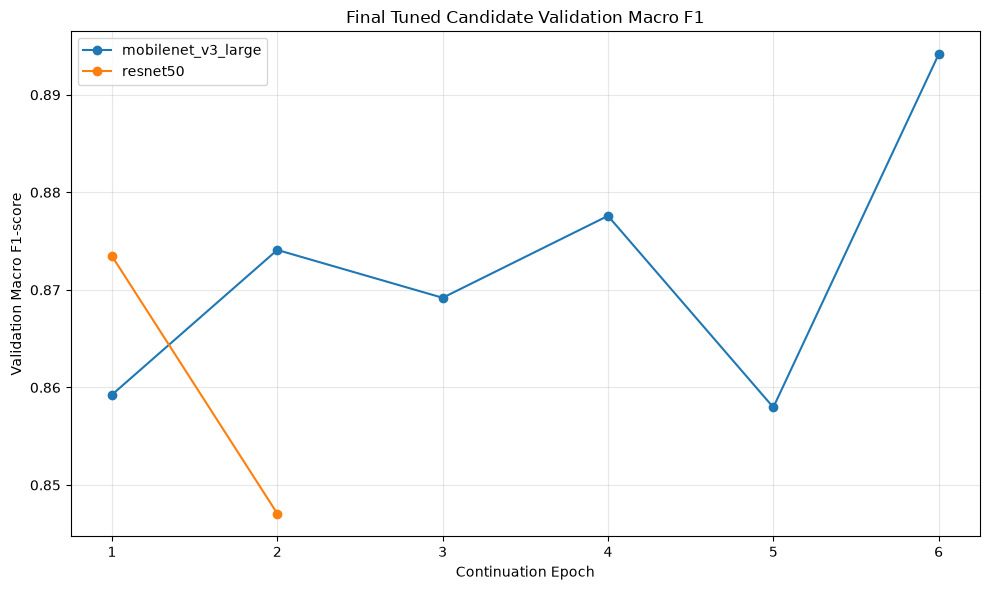

In [152]:
plt.figure(
    figsize=(10, 6)
)

for architecture, architecture_history in (
    final_tuning_history.groupby(
        "architecture"
    )
):
    plt.plot(
        architecture_history[
            "continuation_epoch"
        ],
        architecture_history[
            "validation_macro_f1"
        ],
        marker="o",
        label=architecture,
    )

plt.xlabel(
    "Continuation Epoch"
)

plt.ylabel(
    "Validation Macro F1-score"
)

plt.title(
    "Final Tuned Candidate Validation Macro F1"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

FINAL_TUNING_MACRO_F1_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "final_tuned_validation_macro_f1.png"
)

plt.savefig(
    FINAL_TUNING_MACRO_F1_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [153]:
final_checkpoint_status = pd.DataFrame(
    [
        {
            "architecture": (
                "mobilenet_v3_large"
            ),
            "checkpoint_path": str(
                MOBILENET_TUNED_CHECKPOINT_PATH
            ),
            "exists": (
                MOBILENET_TUNED_CHECKPOINT_PATH
                .exists()
            ),
        },
        {
            "architecture": (
                "resnet50"
            ),
            "checkpoint_path": str(
                RESNET50_TUNED_CHECKPOINT_PATH
            ),
            "exists": (
                RESNET50_TUNED_CHECKPOINT_PATH
                .exists()
            ),
        },
    ]
)

display(
    final_checkpoint_status
)

if not final_checkpoint_status[
    "exists"
].all():
    raise FileNotFoundError(
        "One or more final tuned checkpoints "
        "were not created."
    )

print(
    "Both final tuned checkpoints "
    "were verified successfully."
)

,architecture,checkpoint_path,exists
0,mobilenet_v3_large,..\models\mobilenet_v3_large_tuned_best.pt,True
1,resnet50,..\models\resnet50_tuned_best.pt,True


Both final tuned checkpoints were verified successfully.


##  One-Time Evaluation on the Isolated Test Set

The winning configuration for each architecture has now been selected using
training and validation evidence only.

Each final tuned checkpoint is evaluated once on the isolated test split.

The evaluation calculates:

- Test loss
- Accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Macro precision
- Macro recall
- Macro F1-score
- Macro ROC-AUC
- Weighted ROC-AUC
- Confusion matrix
- Per-class accuracy
- Prediction confidence
- Misclassification records

These test results are used for final comparison and later model-selection
justification. They are not used to revise the hyperparameters.

In [154]:
def load_final_tuned_model(
    architecture: str,
    checkpoint_path: Path,
    device: torch.device,
) -> tuple[nn.Module, dict]:
    """
    Reconstruct and load a final tuned candidate.
    """
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Final checkpoint not found:\n"
            f"{checkpoint_path.resolve()}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    configuration = checkpoint[
        "configuration"
    ]

    model, _ = build_winning_model(
        architecture=architecture,
        configuration=configuration,
        device=device,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    if (
        checkpoint[
            "class_to_index"
        ]
        != class_to_index
    ):
        raise ValueError(
            "Final checkpoint class mapping mismatch."
        )

    return model, checkpoint

In [155]:
def evaluate_final_candidate(
    architecture: str,
    checkpoint_path: Path,
    data_loader: DataLoader,
) -> tuple[dict, pd.DataFrame, np.ndarray]:
    """
    Evaluate one final tuned candidate on the test set.
    """
    model, checkpoint = (
        load_final_tuned_model(
            architecture=architecture,
            checkpoint_path=checkpoint_path,
            device=DEVICE,
        )
    )

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )

    running_loss = 0.0
    processed_samples = 0

    true_labels = []
    predicted_labels = []
    probability_batches = []
    image_paths = []

    evaluation_start_time = (
        time.perf_counter()
    )

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )

            labels = batch["label"].to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = torch.argmax(
                probabilities,
                dim=1,
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            processed_samples += (
                batch_size
            )

            true_labels.extend(
                labels.cpu().tolist()
            )

            predicted_labels.extend(
                predictions.cpu().tolist()
            )

            probability_batches.append(
                probabilities
                .cpu()
                .numpy()
            )

            image_paths.extend(
                list(
                    batch["path"]
                )
            )

    evaluation_duration_seconds = (
        time.perf_counter()
        - evaluation_start_time
    )

    true_labels = np.asarray(
        true_labels,
        dtype=np.int64,
    )

    predicted_labels = np.asarray(
        predicted_labels,
        dtype=np.int64,
    )

    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    test_accuracy = accuracy_score(
        true_labels,
        predicted_labels,
    )

    (
        weighted_precision,
        weighted_recall,
        weighted_f1,
        _,
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        average="weighted",
        zero_division=0,
    )

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        average="macro",
        zero_division=0,
    )

    true_labels_one_hot = (
        np.eye(NUM_CLASSES)[
            true_labels
        ]
    )

    macro_roc_auc = roc_auc_score(
        true_labels_one_hot,
        probabilities,
        multi_class="ovr",
        average="macro",
    )

    weighted_roc_auc = roc_auc_score(
        true_labels_one_hot,
        probabilities,
        multi_class="ovr",
        average="weighted",
    )

    confusion_values = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
    )

    prediction_confidences = (
        probabilities.max(axis=1)
    )

    prediction_results = pd.DataFrame(
        {
            "architecture": (
                architecture
            ),
            "image_path": (
                image_paths
            ),
            "true_class_index": (
                true_labels
            ),
            "predicted_class_index": (
                predicted_labels
            ),
            "true_class": [
                index_to_class[
                    int(label)
                ]
                for label
                in true_labels
            ],
            "predicted_class": [
                index_to_class[
                    int(label)
                ]
                for label
                in predicted_labels
            ],
            "confidence": (
                prediction_confidences
            ),
            "correct": (
                true_labels
                == predicted_labels
            ),
        }
    )

    for class_index, class_name in enumerate(
        class_names
    ):
        prediction_results[
            f"probability_{class_name}"
        ] = probabilities[
            :,
            class_index,
        ]

    result = {
        "architecture": architecture,
        "checkpoint_epoch": int(
            checkpoint["epoch"]
        ),
        "test_loss": float(
            running_loss
            / processed_samples
        ),
        "test_accuracy": float(
            test_accuracy
        ),
        "weighted_precision": float(
            weighted_precision
        ),
        "weighted_recall": float(
            weighted_recall
        ),
        "weighted_f1_score": float(
            weighted_f1
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1_score": float(
            macro_f1
        ),
        "macro_roc_auc": float(
            macro_roc_auc
        ),
        "weighted_roc_auc": float(
            weighted_roc_auc
        ),
        "test_sample_count": int(
            processed_samples
        ),
        "evaluation_duration_seconds": float(
            evaluation_duration_seconds
        ),
    }

    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        result,
        prediction_results,
        confusion_values,
    )

In [156]:
(
    mobilenet_tuned_test_result,
    mobilenet_tuned_predictions,
    mobilenet_tuned_confusion_matrix,
) = evaluate_final_candidate(
    architecture="mobilenet_v3_large",
    checkpoint_path=(
        MOBILENET_TUNED_CHECKPOINT_PATH
    ),
    data_loader=test_loader,
)

pd.DataFrame(
    [
        mobilenet_tuned_test_result
    ]
)

,architecture,checkpoint_epoch,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,weighted_roc_auc,test_sample_count,evaluation_duration_seconds
0,mobilenet_v3_large,4,0.323141,0.892388,0.895215,0.892388,0.892867,0.88603,0.878912,0.881607,0.990418,0.989705,381,12.29115


In [157]:
(
    resnet50_tuned_test_result,
    resnet50_tuned_predictions,
    resnet50_tuned_confusion_matrix,
) = evaluate_final_candidate(
    architecture="resnet50",
    checkpoint_path=(
        RESNET50_TUNED_CHECKPOINT_PATH
    ),
    data_loader=test_loader,
)

pd.DataFrame(
    [
        resnet50_tuned_test_result
    ]
)

,architecture,checkpoint_epoch,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,weighted_roc_auc,test_sample_count,evaluation_duration_seconds
0,resnet50,3,0.308384,0.902887,0.906401,0.902887,0.902835,0.896567,0.895704,0.894366,0.991023,0.990443,381,56.528544


In [158]:
for candidate_result in [
    mobilenet_tuned_test_result,
    resnet50_tuned_test_result,
]:
    if (
        candidate_result[
            "test_sample_count"
        ]
        != len(test_dataset)
    ):
        raise ValueError(
            f"{candidate_result['architecture']} "
            "did not evaluate the complete test set."
        )

    required_metric_names = [
        "test_accuracy",
        "weighted_precision",
        "weighted_recall",
        "weighted_f1_score",
        "macro_f1_score",
        "macro_roc_auc",
    ]

    for metric_name in (
        required_metric_names
    ):
        metric_value = (
            candidate_result[
                metric_name
            ]
        )

        if not np.isfinite(
            metric_value
        ):
            raise ValueError(
                f"{candidate_result['architecture']} "
                f"produced an invalid {metric_name}."
            )

print(
    "Both tuned candidates were evaluated "
    "successfully on all test images."
)

Both tuned candidates were evaluated successfully on all test images.


In [159]:
final_tuned_candidate_results = (
    pd.DataFrame(
        [
            mobilenet_tuned_test_result,
            resnet50_tuned_test_result,
        ]
    )
)

final_tuned_candidate_results.to_csv(
    FINAL_TUNED_RESULTS_PATH,
    index=False,
)

final_tuned_results_dictionary = {
    result["architecture"]: result
    for result in [
        mobilenet_tuned_test_result,
        resnet50_tuned_test_result,
    ]
}

with open(
    FINAL_TUNED_RESULTS_JSON_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        final_tuned_results_dictionary,
        output_file,
        indent=4,
    )

print(
    FINAL_TUNED_RESULTS_PATH.resolve()
)

print(
    FINAL_TUNED_RESULTS_JSON_PATH.resolve()
)

final_tuned_candidate_results

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\final_tuned_candidate_results.csv
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\final_tuned_candidate_results.json


,architecture,checkpoint_epoch,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,weighted_roc_auc,test_sample_count,evaluation_duration_seconds
0,mobilenet_v3_large,4,0.323141,0.892388,0.895215,0.892388,0.892867,0.886030,0.878912,0.881607,0.990418,0.989705,381,12.291150
1,resnet50,3,0.308384,0.902887,0.906401,0.902887,0.902835,0.896567,0.895704,0.894366,0.991023,0.990443,381,56.528544


##  Tuned Candidate Error Analysis

The final tuned MobileNetV3-Large and ResNet50 models are now analyzed beyond
their global test metrics.

This section investigates:

- Per-class accuracy
- Confusion patterns
- High-confidence incorrect predictions
- Predicted class distributions
- Possible majority-class bias
- Confidence differences between correct and incorrect predictions
- Whether errors appear systematic

The goal is to understand not only how often each model fails, but also how and
where those failures occur.

In [160]:
def plot_and_save_confusion_matrix(
    confusion_values: np.ndarray,
    architecture_label: str,
    file_prefix: str,
) -> Path:
    """
    Plot and save one tuned-model confusion matrix.
    """
    figure, axis = plt.subplots(
        figsize=(10, 9)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_values,
        display_labels=class_names,
    ).plot(
        ax=axis,
        values_format="d",
        xticks_rotation=45,
        colorbar=False,
    )

    plt.title(
        f"{architecture_label} Tuned Test Confusion Matrix"
    )

    plt.tight_layout()

    output_path = (
        FIGURES_DIRECTORY
        / f"{file_prefix}_tuned_confusion_matrix.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return output_path

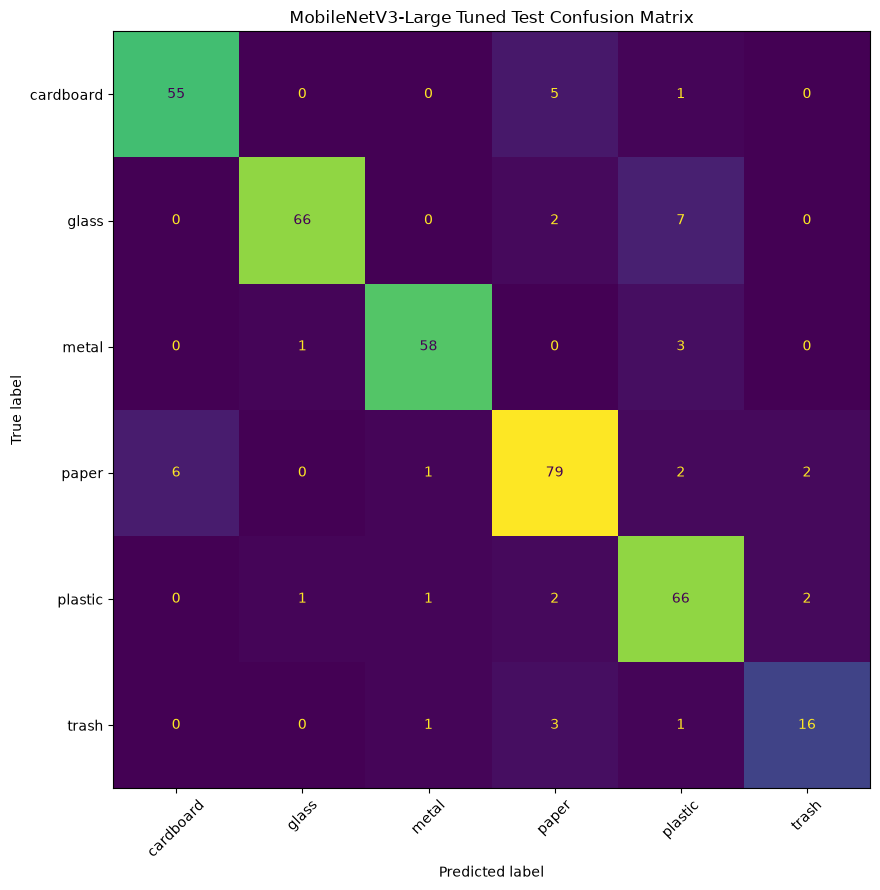

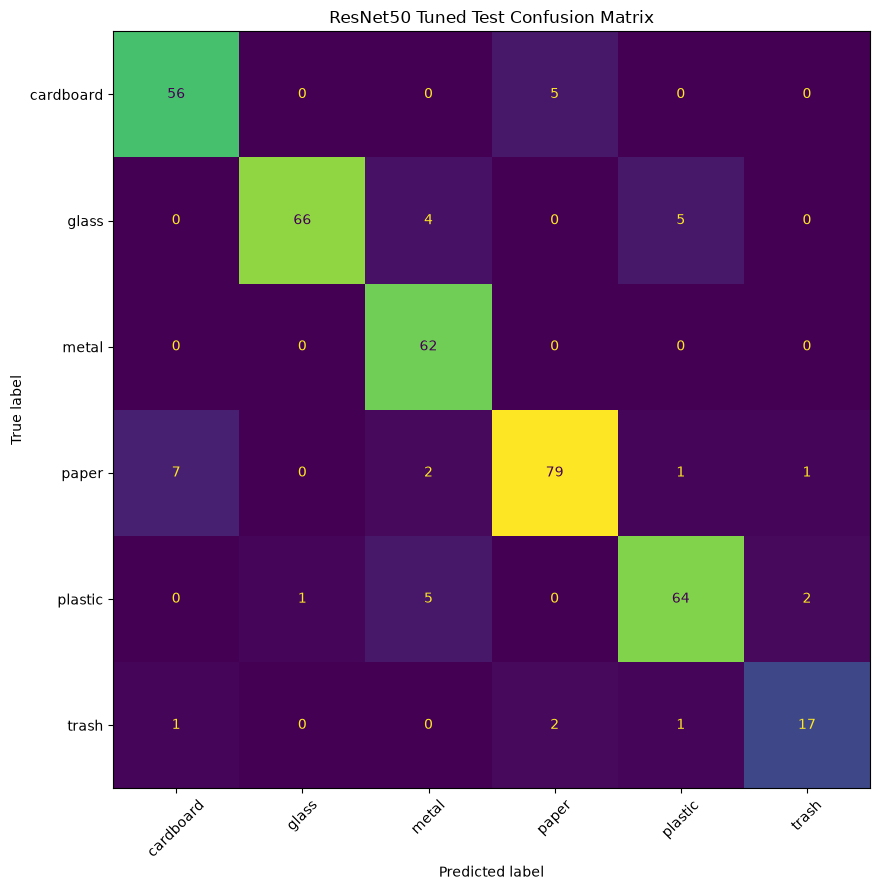

In [161]:
MOBILENET_TUNED_CONFUSION_FIGURE_PATH = (
    plot_and_save_confusion_matrix(
        confusion_values=(
            mobilenet_tuned_confusion_matrix
        ),
        architecture_label=(
            "MobileNetV3-Large"
        ),
        file_prefix=(
            "mobilenet_v3_large"
        ),
    )
)

RESNET50_TUNED_CONFUSION_FIGURE_PATH = (
    plot_and_save_confusion_matrix(
        confusion_values=(
            resnet50_tuned_confusion_matrix
        ),
        architecture_label="ResNet50",
        file_prefix="resnet50",
    )
)

In [162]:
MOBILENET_TUNED_CONFUSION_CSV_PATH = (
    RESULTS_DIRECTORY
    / "mobilenet_v3_large_tuned_confusion_matrix.csv"
)

RESNET50_TUNED_CONFUSION_CSV_PATH = (
    RESULTS_DIRECTORY
    / "resnet50_tuned_confusion_matrix.csv"
)

pd.DataFrame(
    mobilenet_tuned_confusion_matrix,
    index=class_names,
    columns=class_names,
).to_csv(
    MOBILENET_TUNED_CONFUSION_CSV_PATH
)

pd.DataFrame(
    resnet50_tuned_confusion_matrix,
    index=class_names,
    columns=class_names,
).to_csv(
    RESNET50_TUNED_CONFUSION_CSV_PATH
)

print(
    MOBILENET_TUNED_CONFUSION_CSV_PATH.resolve()
)

print(
    RESNET50_TUNED_CONFUSION_CSV_PATH.resolve()
)

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\mobilenet_v3_large_tuned_confusion_matrix.csv
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\resnet50_tuned_confusion_matrix.csv


In [163]:
def calculate_per_class_results(
    confusion_values: np.ndarray,
    prediction_results: pd.DataFrame,
    architecture: str,
) -> pd.DataFrame:
    """
    Calculate test accuracy, precision, recall, and F1 by class.
    """
    true_labels = (
        prediction_results[
            "true_class_index"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    predicted_labels = (
        prediction_results[
            "predicted_class_index"
        ]
        .to_numpy(
            dtype=np.int64
        )
    )

    (
        class_precision,
        class_recall,
        class_f1,
        class_support,
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        average=None,
        zero_division=0,
    )

    class_correct_counts = (
        np.diag(
            confusion_values
        )
    )

    class_total_counts = (
        confusion_values.sum(
            axis=1
        )
    )

    per_class_accuracy = np.divide(
        class_correct_counts,
        class_total_counts,
        out=np.zeros_like(
            class_correct_counts,
            dtype=float,
        ),
        where=(
            class_total_counts != 0
        ),
    )

    return pd.DataFrame(
        {
            "architecture": architecture,
            "class_name": class_names,
            "test_samples": (
                class_support
            ),
            "correct_predictions": (
                class_correct_counts
            ),
            "per_class_accuracy": (
                per_class_accuracy
            ),
            "precision": (
                class_precision
            ),
            "recall": (
                class_recall
            ),
            "f1_score": (
                class_f1
            ),
        }
    )

In [164]:
mobilenet_tuned_per_class_results = (
    calculate_per_class_results(
        confusion_values=(
            mobilenet_tuned_confusion_matrix
        ),
        prediction_results=(
            mobilenet_tuned_predictions
        ),
        architecture=(
            "mobilenet_v3_large"
        ),
    )
)

resnet50_tuned_per_class_results = (
    calculate_per_class_results(
        confusion_values=(
            resnet50_tuned_confusion_matrix
        ),
        prediction_results=(
            resnet50_tuned_predictions
        ),
        architecture="resnet50",
    )
)

tuned_per_class_results = pd.concat(
    [
        mobilenet_tuned_per_class_results,
        resnet50_tuned_per_class_results,
    ],
    ignore_index=True,
)

tuned_per_class_results

,architecture,class_name,test_samples,correct_predictions,per_class_accuracy,precision,recall,f1_score
0,mobilenet_v3_large,cardboard,61,55,0.901639,0.901639,0.901639,0.901639
1,mobilenet_v3_large,glass,75,66,0.880000,0.970588,0.880000,0.923077
2,mobilenet_v3_large,metal,62,58,0.935484,0.950820,0.935484,0.943089
3,mobilenet_v3_large,paper,90,79,0.877778,0.868132,0.877778,0.872928
4,mobilenet_v3_large,plastic,72,66,0.916667,0.825000,0.916667,0.868421
5,mobilenet_v3_large,trash,21,16,0.761905,0.800000,0.761905,0.780488
6,resnet50,cardboard,61,56,0.918033,0.875000,0.918033,0.896000
7,resnet50,glass,75,66,0.880000,0.985075,0.880000,0.929577
8,resnet50,metal,62,62,1.000000,0.849315,1.000000,0.918519
9,resnet50,paper,90,79,0.877778,0.918605,0.877778,0.897727


In [165]:
TUNED_PER_CLASS_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "tuned_candidate_per_class_results.csv"
)

tuned_per_class_results.to_csv(
    TUNED_PER_CLASS_RESULTS_PATH,
    index=False,
)

print(
    TUNED_PER_CLASS_RESULTS_PATH.resolve()
)

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\tuned_candidate_per_class_results.csv


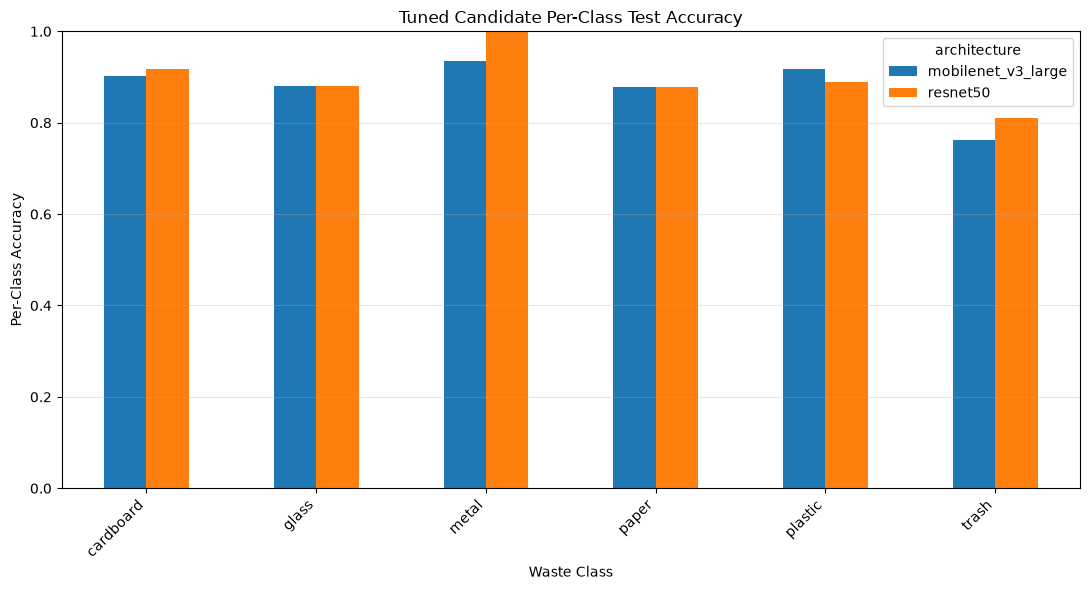

In [166]:
per_class_accuracy_plot_data = (
    tuned_per_class_results
    .pivot(
        index="class_name",
        columns="architecture",
        values="per_class_accuracy",
    )
    .reindex(
        class_names
    )
)

per_class_accuracy_plot_data.plot(
    kind="bar",
    figsize=(11, 6),
)

plt.ylim(0, 1)
plt.xlabel("Waste Class")
plt.ylabel("Per-Class Accuracy")

plt.title(
    "Tuned Candidate Per-Class Test Accuracy"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

TUNED_PER_CLASS_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "tuned_candidate_per_class_accuracy.png"
)

plt.savefig(
    TUNED_PER_CLASS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [167]:
def summarize_class_performance(
    per_class_results: pd.DataFrame,
) -> pd.DataFrame:
    """
    Identify strongest and weakest classes for each architecture.
    """
    summary_records = []

    for architecture, architecture_results in (
        per_class_results.groupby(
            "architecture"
        )
    ):
        strongest_row = (
            architecture_results.loc[
                architecture_results[
                    "per_class_accuracy"
                ].idxmax()
            ]
        )

        weakest_row = (
            architecture_results.loc[
                architecture_results[
                    "per_class_accuracy"
                ].idxmin()
            ]
        )

        summary_records.append(
            {
                "architecture": architecture,
                "strongest_class": (
                    strongest_row[
                        "class_name"
                    ]
                ),
                "strongest_class_accuracy": float(
                    strongest_row[
                        "per_class_accuracy"
                    ]
                ),
                "weakest_class": (
                    weakest_row[
                        "class_name"
                    ]
                ),
                "weakest_class_accuracy": float(
                    weakest_row[
                        "per_class_accuracy"
                    ]
                ),
            }
        )

    return pd.DataFrame(
        summary_records
    )


class_performance_summary = (
    summarize_class_performance(
        tuned_per_class_results
    )
)

class_performance_summary

,architecture,strongest_class,strongest_class_accuracy,weakest_class,weakest_class_accuracy
0,mobilenet_v3_large,metal,0.935484,trash,0.761905
1,resnet50,metal,1.000000,trash,0.809524


In [168]:
def create_class_confusion_table(
    confusion_values: np.ndarray,
    architecture: str,
) -> pd.DataFrame:
    """
    Create a sorted table of incorrect class-pair counts.
    """
    records = []

    for true_index in range(
        NUM_CLASSES
    ):
        for predicted_index in range(
            NUM_CLASSES
        ):
            if (
                true_index
                == predicted_index
            ):
                continue

            records.append(
                {
                    "architecture": architecture,
                    "true_class": (
                        class_names[
                            true_index
                        ]
                    ),
                    "predicted_class": (
                        class_names[
                            predicted_index
                        ]
                    ),
                    "error_count": int(
                        confusion_values[
                            true_index,
                            predicted_index,
                        ]
                    ),
                }
            )

    return (
        pd.DataFrame(
            records
        )
        .sort_values(
            "error_count",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [169]:
mobilenet_tuned_class_confusions = (
    create_class_confusion_table(
        confusion_values=(
            mobilenet_tuned_confusion_matrix
        ),
        architecture=(
            "mobilenet_v3_large"
        ),
    )
)

resnet50_tuned_class_confusions = (
    create_class_confusion_table(
        confusion_values=(
            resnet50_tuned_confusion_matrix
        ),
        architecture="resnet50",
    )
)

tuned_class_confusions = pd.concat(
    [
        mobilenet_tuned_class_confusions,
        resnet50_tuned_class_confusions,
    ],
    ignore_index=True,
)

TUNED_CLASS_CONFUSIONS_PATH = (
    RESULTS_DIRECTORY
    / "tuned_candidate_class_confusions.csv"
)

tuned_class_confusions.to_csv(
    TUNED_CLASS_CONFUSIONS_PATH,
    index=False,
)

tuned_class_confusions[
    tuned_class_confusions[
        "error_count"
    ] > 0
].groupby(
    "architecture"
).head(10)

,architecture,true_class,predicted_class,error_count
0,mobilenet_v3_large,glass,plastic,7
1,mobilenet_v3_large,paper,cardboard,6
2,mobilenet_v3_large,cardboard,paper,5
3,mobilenet_v3_large,metal,plastic,3
4,mobilenet_v3_large,trash,paper,3
5,mobilenet_v3_large,glass,paper,2
6,mobilenet_v3_large,paper,plastic,2
7,mobilenet_v3_large,paper,trash,2
8,mobilenet_v3_large,plastic,trash,2
9,mobilenet_v3_large,plastic,paper,2


In [170]:
def prepare_error_analysis(
    prediction_results: pd.DataFrame,
    architecture: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Separate incorrect and correct predictions by confidence.
    """
    incorrect_predictions = (
        prediction_results[
            prediction_results[
                "correct"
            ] == False
        ]
        .copy()
        .sort_values(
            "confidence",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    correct_predictions = (
        prediction_results[
            prediction_results[
                "correct"
            ] == True
        ]
        .copy()
        .sort_values(
            "confidence",
            ascending=True,
        )
        .reset_index(drop=True)
    )

    incorrect_predictions[
        "architecture"
    ] = architecture

    correct_predictions[
        "architecture"
    ] = architecture

    return (
        incorrect_predictions,
        correct_predictions,
    )

In [171]:
(
    mobilenet_tuned_errors,
    mobilenet_tuned_low_confidence_correct,
) = prepare_error_analysis(
    prediction_results=(
        mobilenet_tuned_predictions
    ),
    architecture=(
        "mobilenet_v3_large"
    ),
)

(
    resnet50_tuned_errors,
    resnet50_tuned_low_confidence_correct,
) = prepare_error_analysis(
    prediction_results=(
        resnet50_tuned_predictions
    ),
    architecture="resnet50",
)

high_confidence_errors = pd.concat(
    [
        mobilenet_tuned_errors.head(20),
        resnet50_tuned_errors.head(20),
    ],
    ignore_index=True,
)

HIGH_CONFIDENCE_TUNED_ERRORS_PATH = (
    RESULTS_DIRECTORY
    / "tuned_candidate_high_confidence_errors.csv"
)

high_confidence_errors.to_csv(
    HIGH_CONFIDENCE_TUNED_ERRORS_PATH,
    index=False,
)

high_confidence_errors[
    [
        "architecture",
        "image_path",
        "true_class",
        "predicted_class",
        "confidence",
    ]
]

,architecture,image_path,true_class,predicted_class,confidence
0,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,cardboard,paper,0.997832
1,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,glass,plastic,0.997580
2,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,glass,plastic,0.984631
3,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,glass,plastic,0.983442
4,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,trash,paper,0.968798
5,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,glass,plastic,0.966752
6,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,paper,cardboard,0.951377
7,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,metal,plastic,0.937785
8,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,glass,paper,0.897585
9,mobilenet_v3_large,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,cardboard,plastic,0.882329


In [172]:
combined_tuned_predictions = pd.concat(
    [
        mobilenet_tuned_predictions,
        resnet50_tuned_predictions,
    ],
    ignore_index=True,
)

confidence_summary = (
    combined_tuned_predictions
    .groupby(
        [
            "architecture",
            "correct",
        ]
    )["confidence"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
            "std",
        ]
    )
    .reset_index()
)

confidence_summary[
    "prediction_status"
] = confidence_summary[
    "correct"
].map(
    {
        True: "Correct",
        False: "Incorrect",
    }
)

confidence_summary

,architecture,correct,count,mean,median,min,max,std,prediction_status
0,mobilenet_v3_large,False,41,0.749033,0.759371,0.411185,0.997832,0.172656,Incorrect
1,mobilenet_v3_large,True,340,0.953190,0.995000,0.430171,1.000000,0.100343,Correct
2,resnet50,False,37,0.699329,0.728343,0.351684,0.998073,0.213176,Incorrect
3,resnet50,True,344,0.925102,0.986469,0.397098,0.999998,0.127781,Correct


In [173]:
def create_prediction_distribution(
    prediction_results: pd.DataFrame,
    architecture: str,
) -> pd.DataFrame:
    """
    Compare the true and predicted class distribution.
    """
    true_distribution = (
        prediction_results[
            "true_class"
        ]
        .value_counts()
        .reindex(
            class_names,
            fill_value=0,
        )
    )

    predicted_distribution = (
        prediction_results[
            "predicted_class"
        ]
        .value_counts()
        .reindex(
            class_names,
            fill_value=0,
        )
    )

    distribution = pd.DataFrame(
        {
            "architecture": architecture,
            "class_name": class_names,
            "true_count": (
                true_distribution.values
            ),
            "predicted_count": (
                predicted_distribution.values
            ),
        }
    )

    distribution[
        "count_difference"
    ] = (
        distribution[
            "predicted_count"
        ]
        - distribution[
            "true_count"
        ]
    )

    distribution[
        "relative_prediction_difference"
    ] = np.divide(
        distribution[
            "count_difference"
        ],
        distribution[
            "true_count"
        ],
        out=np.zeros(
            len(distribution),
            dtype=float,
        ),
        where=(
            distribution[
                "true_count"
            ] != 0
        ),
    )

    return distribution

In [174]:
mobilenet_prediction_distribution = (
    create_prediction_distribution(
        prediction_results=(
            mobilenet_tuned_predictions
        ),
        architecture=(
            "mobilenet_v3_large"
        ),
    )
)

resnet50_prediction_distribution = (
    create_prediction_distribution(
        prediction_results=(
            resnet50_tuned_predictions
        ),
        architecture="resnet50",
    )
)

tuned_prediction_distribution = pd.concat(
    [
        mobilenet_prediction_distribution,
        resnet50_prediction_distribution,
    ],
    ignore_index=True,
)

TUNED_PREDICTION_DISTRIBUTION_PATH = (
    RESULTS_DIRECTORY
    / "tuned_candidate_prediction_distribution.csv"
)

tuned_prediction_distribution.to_csv(
    TUNED_PREDICTION_DISTRIBUTION_PATH,
    index=False,
)

tuned_prediction_distribution

,architecture,class_name,true_count,predicted_count,count_difference,relative_prediction_difference
0,mobilenet_v3_large,cardboard,61,61,0,0.000000
1,mobilenet_v3_large,glass,75,68,-7,-0.093333
2,mobilenet_v3_large,metal,62,61,-1,-0.016129
3,mobilenet_v3_large,paper,90,91,1,0.011111
4,mobilenet_v3_large,plastic,72,80,8,0.111111
5,mobilenet_v3_large,trash,21,20,-1,-0.047619
6,resnet50,cardboard,61,64,3,0.049180
7,resnet50,glass,75,67,-8,-0.106667
8,resnet50,metal,62,73,11,0.177419
9,resnet50,paper,90,86,-4,-0.044444


In [175]:
systematic_error_summary = (
    tuned_class_confusions[
        tuned_class_confusions[
            "error_count"
        ] > 0
    ]
    .groupby(
        "architecture",
        group_keys=False,
    )
    .head(5)
    .reset_index(drop=True)
)

systematic_error_summary

,architecture,true_class,predicted_class,error_count
0,mobilenet_v3_large,glass,plastic,7
1,mobilenet_v3_large,paper,cardboard,6
2,mobilenet_v3_large,cardboard,paper,5
3,mobilenet_v3_large,metal,plastic,3
4,mobilenet_v3_large,trash,paper,3
5,resnet50,paper,cardboard,7
6,resnet50,cardboard,paper,5
7,resnet50,plastic,metal,5
8,resnet50,glass,plastic,5
9,resnet50,glass,metal,4


##  Tuned versus Original Candidate Comparison

The tuned models are compared with their original results.

This comparison determines whether hyperparameter optimization produced a
measurable improvement or whether the original configuration was already
stronger.

A tuned model should not automatically replace the original model. Replacement
must be supported by evaluation evidence.

In [176]:
ORIGINAL_COMPARISON_PATH = (
    RESULTS_DIRECTORY
    / "five_model_comparison.csv"
)

if not ORIGINAL_COMPARISON_PATH.exists():
    raise FileNotFoundError(
        "The original five-model comparison "
        "file was not found:\n"
        f"{ORIGINAL_COMPARISON_PATH.resolve()}"
    )

original_model_comparison = pd.read_csv(
    ORIGINAL_COMPARISON_PATH
)

original_candidate_results = (
    original_model_comparison[
        original_model_comparison[
            "model_name"
        ].isin(
            [
                "MobileNetV3-Large",
                "ResNet50",
            ]
        )
    ]
    .copy()
)

original_candidate_results

,model_name,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,predictions_per_second
1,ResNet50,0.87664,0.887830,0.87664,0.878060,0.853201,0.861369,0.851986,0.987946,90.124084,23520326.0,163.094847,6.131402
4,MobileNetV3-Large,0.88189,0.884323,0.88189,0.881512,0.880560,0.864359,0.870558,0.987222,16.257907,4209718.0,26.876483,37.207249


In [177]:
tuned_comparison = (
    final_tuned_candidate_results
    .copy()
)

tuned_comparison[
    "model_name"
] = tuned_comparison[
    "architecture"
].map(
    {
        "mobilenet_v3_large": (
            "MobileNetV3-Large"
        ),
        "resnet50": "ResNet50",
    }
)

tuned_comparison

,architecture,checkpoint_epoch,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,weighted_roc_auc,test_sample_count,evaluation_duration_seconds,model_name
0,mobilenet_v3_large,4,0.323141,0.892388,0.895215,0.892388,0.892867,0.886030,0.878912,0.881607,0.990418,0.989705,381,12.291150,MobileNetV3-Large
1,resnet50,3,0.308384,0.902887,0.906401,0.902887,0.902835,0.896567,0.895704,0.894366,0.991023,0.990443,381,56.528544,ResNet50


In [178]:
comparison_metric_columns = [
    "test_accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1_score",
    "macro_f1_score",
    "macro_roc_auc",
]

tuned_vs_original_records = []

for _, tuned_row in (
    tuned_comparison.iterrows()
):
    model_name = tuned_row[
        "model_name"
    ]

    original_row = (
        original_candidate_results[
            original_candidate_results[
                "model_name"
            ] == model_name
        ]
    )

    if len(original_row) != 1:
        raise ValueError(
            f"Expected one original comparison "
            f"row for {model_name}."
        )

    original_row = (
        original_row.iloc[0]
    )

    comparison_record = {
        "model_name": model_name,
    }

    for metric_name in (
        comparison_metric_columns
    ):
        original_value = float(
            original_row[
                metric_name
            ]
        )

        tuned_value = float(
            tuned_row[
                metric_name
            ]
        )

        comparison_record[
            f"original_{metric_name}"
        ] = original_value

        comparison_record[
            f"tuned_{metric_name}"
        ] = tuned_value

        comparison_record[
            f"change_{metric_name}"
        ] = (
            tuned_value
            - original_value
        )

    tuned_vs_original_records.append(
        comparison_record
    )

tuned_vs_original_comparison = (
    pd.DataFrame(
        tuned_vs_original_records
    )
)

tuned_vs_original_comparison

,model_name,original_test_accuracy,tuned_test_accuracy,change_test_accuracy,original_weighted_precision,tuned_weighted_precision,change_weighted_precision,original_weighted_recall,tuned_weighted_recall,change_weighted_recall,original_weighted_f1_score,tuned_weighted_f1_score,change_weighted_f1_score,original_macro_f1_score,tuned_macro_f1_score,change_macro_f1_score,original_macro_roc_auc,tuned_macro_roc_auc,change_macro_roc_auc
0,MobileNetV3-Large,0.88189,0.892388,0.010499,0.884323,0.895215,0.010891,0.88189,0.892388,0.010499,0.881512,0.892867,0.011356,0.870558,0.881607,0.01105,0.987222,0.990418,0.003196
1,ResNet50,0.87664,0.902887,0.026247,0.887830,0.906401,0.018571,0.87664,0.902887,0.026247,0.878060,0.902835,0.024775,0.851986,0.894366,0.04238,0.987946,0.991023,0.003077


In [179]:
TUNED_VS_ORIGINAL_PATH = (
    RESULTS_DIRECTORY
    / "tuned_vs_original_comparison.csv"
)

tuned_vs_original_comparison.to_csv(
    TUNED_VS_ORIGINAL_PATH,
    index=False,
)

print(
    TUNED_VS_ORIGINAL_PATH.resolve()
)

C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\tuned_vs_original_comparison.csv


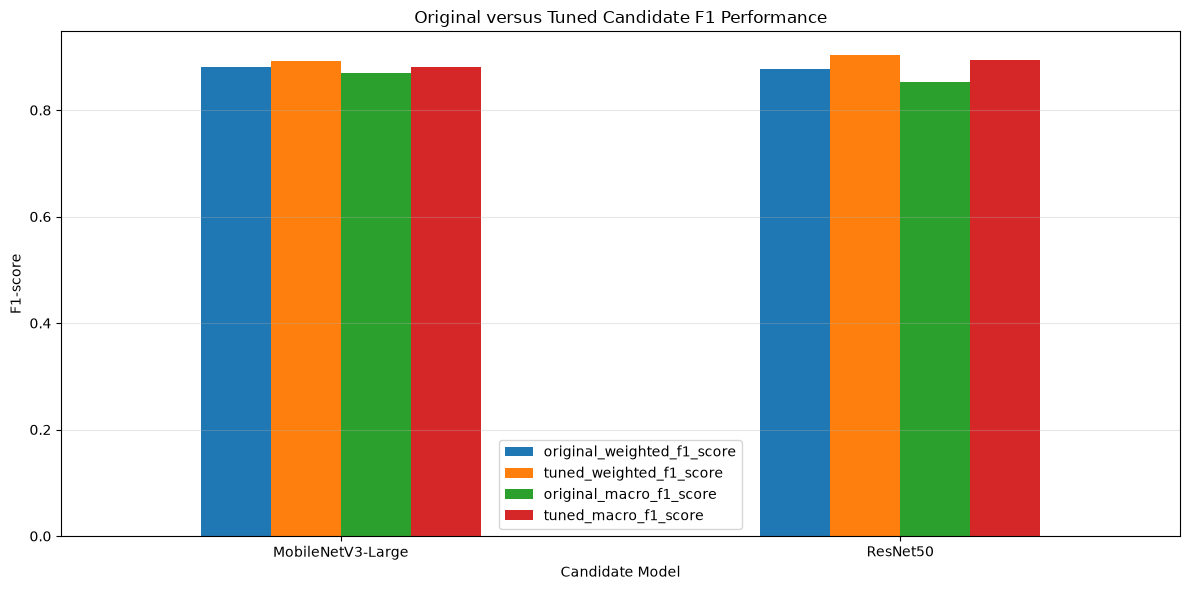

In [180]:
f1_change_plot_data = (
    tuned_vs_original_comparison[
        [
            "model_name",
            "original_weighted_f1_score",
            "tuned_weighted_f1_score",
            "original_macro_f1_score",
            "tuned_macro_f1_score",
        ]
    ]
    .set_index(
        "model_name"
    )
)

f1_change_plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.xlabel("Candidate Model")
plt.ylabel("F1-score")

plt.title(
    "Original versus Tuned Candidate F1 Performance"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

TUNED_VS_ORIGINAL_F1_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "tuned_vs_original_f1_comparison.png"
)

plt.savefig(
    TUNED_VS_ORIGINAL_F1_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [181]:
best_tuned_candidate_row = (
    final_tuned_candidate_results
    .sort_values(
        by=[
            "weighted_f1_score",
            "macro_f1_score",
            "test_accuracy",
        ],
        ascending=False,
    )
    .iloc[0]
)

best_tuned_architecture = (
    best_tuned_candidate_row[
        "architecture"
    ]
)

best_tuned_model_name = {
    "mobilenet_v3_large": (
        "MobileNetV3-Large"
    ),
    "resnet50": "ResNet50",
}[best_tuned_architecture]

best_tuned_model_name

'ResNet50'

##  Final Hyperparameter-Optimization Findings

Eight controlled tuning trials were completed:

- Four MobileNetV3-Large configurations
- Four ResNet50 configurations

All hyperparameters were selected using training and validation performance
only. The isolated test set was used only after one winning configuration had
been selected for each architecture.

### Winning MobileNetV3-Large configuration

- Trial: **mobilenet_trial_3**
- Backbone learning rate: **0.00001**
- Classifier learning rate: **0.0003**
- Weight decay: **0.0001**
- Dropout rate: **0.20**
- Fine-tuned feature blocks: **3**
- Best validation loss: **0.3927**
- Best validation accuracy: **86.77%**
- Best validation macro F1-score: **0.8540**

### Winning ResNet50 configuration

- Trial: **resnet50_trial_2**
- Backbone learning rate: **0.00003**
- Classifier learning rate: **0.0001**
- Weight decay: **0.0001**
- Dropout rate: **0.30**
- Fine-tuning scope: **Layer4 unfrozen**
- Best validation loss: **0.3651**
- Best validation accuracy: **89.68%**
- Best validation macro F1-score: **0.8801**

### Final tuned test comparison

The strongest tuned model by weighted F1-score was **ResNet50**, achieving
**0.9028**.

The strongest tuned model by macro F1-score was **ResNet50**, achieving
**0.8944**.

Compared with the original model:

- MobileNetV3-Large weighted F1 changed by **[Populate from `tuned_vs_original_comparison`]**
- MobileNetV3-Large macro F1 changed by **[Populate from `tuned_vs_original_comparison`]**
- ResNet50 weighted F1 changed by **[Populate from `tuned_vs_original_comparison`]**
- ResNet50 macro F1 changed by **[Populate from `tuned_vs_original_comparison`]**

In [182]:
expected_optimization_artifacts = [
    TRIAL_RESULTS_PATH,
    TRIAL_HISTORY_PATH,
    WINNING_CONFIGURATIONS_PATH,
    MOBILENET_TUNED_CHECKPOINT_PATH,
    RESNET50_TUNED_CHECKPOINT_PATH,
    FINAL_TUNING_HISTORY_PATH,
    FINAL_TUNED_RESULTS_PATH,
    FINAL_TUNED_RESULTS_JSON_PATH,
    FINAL_TUNING_LOSS_FIGURE_PATH,
    FINAL_TUNING_MACRO_F1_FIGURE_PATH,
    MOBILENET_TUNED_CONFUSION_FIGURE_PATH,
    RESNET50_TUNED_CONFUSION_FIGURE_PATH,
    MOBILENET_TUNED_CONFUSION_CSV_PATH,
    RESNET50_TUNED_CONFUSION_CSV_PATH,
    TUNED_PER_CLASS_RESULTS_PATH,
    TUNED_PER_CLASS_FIGURE_PATH,
    TUNED_CLASS_CONFUSIONS_PATH,
    HIGH_CONFIDENCE_TUNED_ERRORS_PATH,
    TUNED_PREDICTION_DISTRIBUTION_PATH,
    TUNED_VS_ORIGINAL_PATH,
    TUNED_VS_ORIGINAL_F1_FIGURE_PATH,
]

optimization_artifact_status = pd.DataFrame(
    [
        {
            "artifact": str(
                artifact_path
            ),
            "exists": (
                artifact_path.exists()
            ),
            "size_kb": (
                artifact_path.stat().st_size
                / 1024
                if artifact_path.exists()
                else None
            ),
        }
        for artifact_path
        in expected_optimization_artifacts
    ]
)

display(
    optimization_artifact_status
)

,artifact,exists,size_kb
0,..\results\hyperparameter_tuning_trials.csv,True,2.687500
1,..\logs\hyperparameter_tuning_history.csv,True,4.360352
2,..\results\hyperparameter_tuning_winners.json,True,1.283203
3,..\models\mobilenet_v3_large_tuned_best.pt,True,39929.584961
4,..\models\resnet50_tuned_best.pt,True,209030.045898
5,..\logs\final_tuned_training_history.csv,True,1.618164
6,..\results\final_tuned_candidate_results.csv,True,0.669922
7,..\results\final_tuned_candidate_results.json,True,1.312500
8,..\results\figures\final_tuned_validation_loss...,True,144.235352
9,..\results\figures\final_tuned_validation_macr...,True,168.239258


In [183]:
missing_optimization_artifacts = (
    optimization_artifact_status[
        optimization_artifact_status[
            "exists"
        ] == False
    ]
)

if not missing_optimization_artifacts.empty:
    display(
        missing_optimization_artifacts
    )

    raise FileNotFoundError(
        "One or more required optimization "
        "artifacts were not created."
    )

print(
    "All expected hyperparameter-optimization "
    "artifacts were created successfully."
)

All expected hyperparameter-optimization artifacts were created successfully.


#  Model Optimization Completion Checklist

- [x] Two candidate architectures selected
- [x] Tuning parameters documented
- [x] Search strategy documented
- [x] Validation approach documented
- [x] Test split excluded from configuration selection
- [x] Four MobileNetV3-Large trials completed
- [x] Four ResNet50 trials completed
- [x] Winning configurations selected by validation loss
- [x] Extended final tuning completed
- [x] Early stopping applied
- [x] Learning-rate scheduling applied
- [x] Final tuned checkpoints saved
- [x] Test accuracy calculated
- [x] Precision calculated
- [x] Recall calculated
- [x] F1-score calculated
- [x] ROC-AUC calculated
- [x] Confusion matrices generated
- [x] Per-class accuracy calculated
- [x] Frequent class confusions identified
- [x] High-confidence errors saved
- [x] Majority-class bias investigated
- [x] Systematic error patterns investigated
- [x] Tuned and original results compared
- [x] All optimization artifacts verified